In [5]:
import json
import pandas as pd

print("\n" + "="*80)
print("PARSING BME688 FILES - SIMPLIFIED VERSION")
print("="*80)

def parse_simple(filepath, label):
    """Simple parser that definitely works"""
    print(f"\nParsing: {filepath}")
    
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    # Get data
    dataBlock = data['rawDataBody']['dataBlock']
    dataColumns = data['rawDataBody']['dataColumns']
    
    # Extract column names from dicts
    column_names = []
    for col in dataColumns:
        if isinstance(col, dict) and 'name' in col:
            column_names.append(col['name'])
        elif isinstance(col, str):
            column_names.append(col)
        else:
            column_names.append(str(col))
    
    # Create DataFrame
    df = pd.DataFrame(dataBlock, columns=column_names)
    
    # Convert to numeric
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        except:
            pass
    
    # Add label
    df['label'] = label
    
    print(f"  ✓ Shape: {df.shape}")
    print(f"  ✓ Columns: {list(df.columns)}")
    
    return df

# Parse all three files
dfs = {}

try:
    df_normal = parse_simple('Normal_air_1.bmerawdata', 'normal')
    df_normal.to_csv('normal_air_1.csv', index=False)
    dfs['normal'] = df_normal
    print(f"  ✓ Saved: normal_air_1.csv")
except Exception as e:
    print(f"  ✗ Error: {e}")

try:
    df_acetone = parse_simple('Aceton_1.bmerawdata', 'acetone')
    df_acetone.to_csv('acetone.csv', index=False)
    dfs['acetone'] = df_acetone
    print(f"  ✓ Saved: acetone.csv")
except Exception as e:
    print(f"  ✗ Error: {e}")

try:
    df_alcohol = parse_simple('Redidlo_2ml_1.bmerawdata', 'alcohol')
    df_alcohol.to_csv('alcohol.csv', index=False)
    dfs['alcohol'] = df_alcohol
    print(f"  ✓ Saved: alcohol.csv")
except Exception as e:
    print(f"  ✗ Error: {e}")

# Combine all
if len(dfs) > 0:
    df_combined = pd.concat(list(dfs.values()), ignore_index=True)
    df_combined.to_csv('combined_data.csv', index=False)
    print(f"\n✓ Combined data saved: combined_data.csv ({len(df_combined)} rows)")

print("\n" + "="*80)
print("PARSING COMPLETE!")
print("="*80)

# Verify
for filename in ['normal_air_1.csv', 'acetone.csv', 'alcohol.csv']:
    try:
        df = pd.read_csv(filename)
        print(f"\n✓ {filename}: {df.shape[0]} rows × {df.shape[1]} columns")
    except:
        pass


PARSING BME688 FILES - SIMPLIFIED VERSION

Parsing: Normal_air_1.bmerawdata
  ✓ Shape: (4494, 14)
  ✓ Columns: ['Sensor Index', 'Sensor ID', 'Time Since PowerOn', 'Real time clock', 'Temperature', 'Pressure', 'Relative Humidity', 'Resistance Gassensor', 'Heater Profile Step Index', 'Scanning Mode Enabled', 'Scanning Cycle Index', 'Label Tag', 'Error Code', 'label']
  ✓ Saved: normal_air_1.csv

Parsing: Aceton_1.bmerawdata
  ✓ Shape: (4645, 14)
  ✓ Columns: ['Sensor Index', 'Sensor ID', 'Time Since PowerOn', 'Real time clock', 'Temperature', 'Pressure', 'Relative Humidity', 'Resistance Gassensor', 'Heater Profile Step Index', 'Scanning Mode Enabled', 'Scanning Cycle Index', 'Label Tag', 'Error Code', 'label']
  ✓ Saved: acetone.csv

Parsing: Redidlo_2ml_1.bmerawdata
  ✗ Error: [Errno 2] No such file or directory: 'Redidlo_2ml_1.bmerawdata'

✓ Combined data saved: combined_data.csv (9139 rows)

PARSING COMPLETE!

✓ normal_air_1.csv: 4494 rows × 14 columns

✓ acetone.csv: 4645 rows × 14 

In [6]:
#!/usr/bin/env python3
"""
Complete BME688 Sensor Data Analysis & ML Pipeline
Includes: Statistics, EDA, Visualization, Feature Engineering, ML Models
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis

# ML & Visualization
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# For UMAP and t-SNE
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠ UMAP not installed. Install with: pip install umap-learn")

from sklearn.manifold import TSNE

# TensorFlow for Autoencoders and LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠ TensorFlow not installed. Install with: pip install tensorflow")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [10]:
# ============================================================================
# PART 1: LOAD AND EXPLORE DATA
# ============================================================================

class BMESensorDataAnalyzer:
    """Complete analysis pipeline for BME688 sensor data"""
    
    def __init__(self, combined_csv_path='combined_data.csv'):
        """Initialize analyzer with combined data"""
        print("\n" + "="*80)
        print("BME688 SENSOR DATA ANALYSIS PIPELINE")
        print("="*80)
        
        self.df = None
        self.X_scaled = None
        self.y = None
        self.feature_cols = None
        self.scaler = StandardScaler()
        
        self.load_data(combined_csv_path)
    
    def load_data(self, filepath):
        """Load combined CSV data"""
        print("\n[STEP 1] LOADING DATA")
        print("-"*80)
        
        self.df = pd.read_csv(filepath)
        print(f"✓ Loaded: {filepath}")
        print(f"  Shape: {self.df.shape}")
        print(f"  Columns: {list(self.df.columns)}")
        
        self.y = self.df['label'].values
        self.feature_cols = [col for col in self.df.columns if col not in ['label', 'measurement_number']]
        
        return self.df
    
    def statistical_analysis(self):
        """Comprehensive statistical analysis"""
        print("\n[STEP 2] STATISTICAL ANALYSIS")
        print("-"*80)
        
        # Overall statistics
        print("\nOVERALL STATISTICS:")
        print(self.df[self.feature_cols].describe())
        
        # Statistics by class
        print("\n\nSTATISTICS BY CLASS:")
        for label in sorted(self.df['label'].unique()):
            print(f"\n{label.upper()}:")
            subset = self.df[self.df['label'] == label][self.feature_cols]
            print(subset.describe())
        
        # Class distribution
        print("\n\nCLASS DISTRIBUTION:")
        class_dist = self.df['label'].value_counts()
        print(class_dist)
        for label, count in class_dist.items():
            print(f"  {label}: {count} ({count/len(self.df)*100:.1f}%)")
        
        # Correlation analysis
        print("\n\nCORRELATION MATRIX:")
        corr = self.df[self.feature_cols].corr()
        print(corr)
        
        return corr
    
    def exploratory_data_analysis(self):
        """EDA visualizations"""
        print("\n[STEP 3] EXPLORATORY DATA ANALYSIS")
        print("-"*80)
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('BME688 Sensor Data - Exploratory Analysis', fontsize=16, fontweight='bold')
        
        # 1. Box plot by class
        ax = axes[0, 0]
        self.df.boxplot(column='temperature', by='label', ax=ax)
        ax.set_title('Temperature by Class')
        ax.set_ylabel('Temperature (°C)')
        
        # 2. Box plot humidity
        ax = axes[0, 1]
        self.df.boxplot(column='humidity', by='label', ax=ax)
        ax.set_title('Humidity by Class')
        ax.set_ylabel('Humidity (%)')
        
        # 3. Box plot gas resistance
        ax = axes[1, 0]
        self.df.boxplot(column='gas_resistance', by='label', ax=ax)
        ax.set_title('Gas Resistance by Class')
        ax.set_ylabel('Resistance (Ω)')
        
        # 4. Box plot pressure
        ax = axes[1, 1]
        self.df.boxplot(column='pressure', by='label', ax=ax)
        ax.set_title('Pressure by Class')
        ax.set_ylabel('Pressure (hPa)')
        
        plt.tight_layout()
        plt.savefig('01_eda_boxplots.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 01_eda_boxplots.png")
        plt.close()
        
        # Distribution plots
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Distribution by Class', fontsize=16, fontweight='bold')
        
        features = ['temperature', 'humidity', 'pressure', 'gas_resistance']
        for idx, feature in enumerate(features):
            ax = axes[idx // 2, idx % 2]
            for label in sorted(self.df['label'].unique()):
                data = self.df[self.df['label'] == label][feature]
                ax.hist(data, alpha=0.5, label=label, bins=30)
            ax.set_xlabel(feature)
            ax.set_ylabel('Frequency')
            ax.set_title(f'{feature.capitalize()} Distribution')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('02_distributions.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 02_distributions.png")
        plt.close()
    
    def prepare_features(self):
        """Prepare and scale features"""
        print("\n[STEP 4] FEATURE PREPARATION")
        print("-"*80)
        
        X = self.df[self.feature_cols].values
        self.X_scaled = self.scaler.fit_transform(X)
        
        print(f"✓ Feature matrix shape: {self.X_scaled.shape}")
        print(f"  Features: {len(self.feature_cols)}")
        print(f"  Samples: {len(self.X_scaled)}")
        print(f"\nFeatures used:")
        for i, col in enumerate(self.feature_cols):
            print(f"  [{i}] {col}")
        
        return self.X_scaled
    
    def correlation_heatmap(self):
        """Visualize correlations"""
        print("\n[STEP 5] CORRELATION ANALYSIS")
        print("-"*80)
        
        # Overall correlation
        fig, ax = plt.subplots(figsize=(10, 8))
        corr = self.df[self.feature_cols].corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   square=True, ax=ax, cbar_kws={'label': 'Correlation'})
        ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 03_correlation_heatmap.png")
        plt.close()
        
        # Per-class correlation
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Correlation Matrix by Class', fontsize=14, fontweight='bold')
        
        for idx, label in enumerate(sorted(self.df['label'].unique())):
            corr_class = self.df[self.df['label'] == label][self.feature_cols].corr()
            sns.heatmap(corr_class, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                       square=True, ax=axes[idx], cbar_kws={'label': 'Correlation'})
            axes[idx].set_title(f'{label.capitalize()}', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('04_correlation_by_class.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 04_correlation_by_class.png")
        plt.close()


In [11]:
#!/usr/bin/env python3
"""
COMPLETE GUIDE: Combining All Separate BME688 Data Files
Shows step-by-step how to merge:
- 5 Normal measurements
- 6 Acetone measurements  
- 7 Alcohol measurements
Into one combined dataset
"""

import json
import pandas as pd
import numpy as np
import os
from pathlib import Path

print("\n" + "="*80)
print("COMPLETE DATA COMBINING GUIDE")
print("="*80)


COMPLETE DATA COMBINING GUIDE


In [12]:
# ============================================================================
# STEP 1: UNDERSTAND YOUR FILE STRUCTURE
# ============================================================================

print("\n[STEP 1] UNDERSTAND FILE STRUCTURE")
print("-"*80)

print("""
My current file structure should be:

my_project_folder/
├── Normal_air_1.bmerawdata
├── Normal_air_2.bmerawdata
├── Normal_air_3.bmerawdata
├── Normal_air_4.bmerawdata
├── Normal_air_5.bmerawdata
├── Normal_air_6.bmerawdata
├── Normal_air_7.bmerawdata
├── Normal_air_9.bmerawdata
├── Aceton_1.bmerawdata
├── Aceton_2.bmerawdata
├── Aceton_3.bmerawdata
├── Aceton_4.bmerawdata
├── Aceton_5.bmerawdata
├── Aceton_6.bmerawdata
TOTAL: 14 files to combine
""")

# List files in current directory
print("\nFiles in current directory:")
files = os.listdir('.')
bmerawdata_files = [f for f in files if f.endswith('.bmerawdata')]
print(f"Found {len(bmerawdata_files)} .bmerawdata files")
for f in sorted(bmerawdata_files):
    print(f"  ✓ {f}")



[STEP 1] UNDERSTAND FILE STRUCTURE
--------------------------------------------------------------------------------

My current file structure should be:

my_project_folder/
├── Normal_air_1.bmerawdata
├── Normal_air_2.bmerawdata
├── Normal_air_3.bmerawdata
├── Normal_air_4.bmerawdata
├── Normal_air_5.bmerawdata
├── Normal_air_6.bmerawdata
├── Normal_air_7.bmerawdata
├── Normal_air_9.bmerawdata
├── Aceton_1.bmerawdata
├── Aceton_2.bmerawdata
├── Aceton_3.bmerawdata
├── Aceton_4.bmerawdata
├── Aceton_5.bmerawdata
├── Aceton_6.bmerawdata
TOTAL: 14 files to combine


Files in current directory:
Found 78 .bmerawdata files
  ✓ Aceton_1.bmerawdata
  ✓ Aceton_2.bmerawdata
  ✓ Aceton_3.bmerawdata
  ✓ Aceton_4.bmerawdata
  ✓ Aceton_5.bmerawdata
  ✓ Aceton_6.bmerawdata
  ✓ Aceton_7A.bmerawdata
  ✓ Aceton_7B.bmerawdata
  ✓ Aceton_7C.bmerawdata
  ✓ Normal_Air_10A.bmerawdata
  ✓ Normal_air_1.bmerawdata
  ✓ Normal_air_10B.bmerawdata
  ✓ Normal_air_11.bmerawdata
  ✓ Normal_air_13.bmerawdata
  ✓ Norm

In [13]:
# ============================================================================
# STEP 2: CREATE HELPER FUNCTION
# ============================================================================

print("\n[STEP 2] CREATE HELPER FUNCTION TO PARSE FILES")
print("-"*80)

def parse_single_bmerawdata_file(filepath):
    """
    Parse a single .bmerawdata file and return DataFrame
    
    Args:
        filepath: Path to .bmerawdata file
    
    Returns:
        pandas.DataFrame with sensor data
    """
    
    try:
        # Load JSON
        with open(filepath, 'r') as f:
            data = json.load(f)
        
        # Extract data block and column names
        dataBlock = data['rawDataBody']['dataBlock']
        dataColumns = data['rawDataBody']['dataColumns']
        
        # Extract column names from dicts
        column_names = []
        for col in dataColumns:
            if isinstance(col, dict) and 'name' in col:
                column_names.append(col['name'])
            elif isinstance(col, str):
                column_names.append(col)
            else:
                column_names.append(str(col))
        
        # Create DataFrame
        df = pd.DataFrame(dataBlock, columns=column_names)
        
        # Convert numeric columns
        numeric_cols = ['Temperature', 'Pressure', 'Relative Humidity', 'Resistance Gassensor']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        return df
    
    except Exception as e:
        print(f"  ✗ Error parsing {filepath}: {e}")
        return None

print("✓ Helper function created")



[STEP 2] CREATE HELPER FUNCTION TO PARSE FILES
--------------------------------------------------------------------------------
✓ Helper function created


In [17]:
# ============================================================================
# STEP 3: PARSE ALL NORMAL FILES
# ============================================================================

print("\n[STEP 3] PARSING NORMAL AIR FILES")
print("-"*80)

normal_dfs = []

for i in range(1, 10):  # 8 normal files
    filename = f'Normal_air_{i}.bmerawdata'
    
    if os.path.exists(filename):
        print(f"  Parsing: {filename}...", end=" ")
        df = parse_single_bmerawdata_file(filename)
        
        if df is not None:
            normal_dfs.append(df)
            print(f"✓ ({len(df)} rows)")
        else:
            print("✗ Failed")
    else:
        print(f"  ⚠ Not found: {filename}")

print(f"\n✓ Loaded {len(normal_dfs)} normal files")


[STEP 3] PARSING NORMAL AIR FILES
--------------------------------------------------------------------------------
  Parsing: Normal_air_1.bmerawdata... ✓ (4494 rows)
  Parsing: Normal_air_2.bmerawdata... ✓ (4455 rows)
  Parsing: Normal_air_3.bmerawdata... ✓ (4242 rows)
  Parsing: Normal_air_4.bmerawdata... ✓ (4508 rows)
  Parsing: Normal_air_5.bmerawdata... ✓ (4419 rows)
  Parsing: Normal_air_6.bmerawdata... ✓ (4420 rows)
  Parsing: Normal_air_7.bmerawdata... ✓ (4435 rows)
  ⚠ Not found: Normal_air_8.bmerawdata
  Parsing: Normal_air_9.bmerawdata... ✓ (4465 rows)

✓ Loaded 8 normal files


In [20]:
# ============================================================================
# STEP 4: COMBINE NORMAL FILES
# ============================================================================

print("\n[STEP 4] COMBINING NORMAL AIR FILES")
print("-"*80)

if len(normal_dfs) > 0:
    # Concatenate all normal air DataFrames
    df_normal_combined_day1 = pd.concat(normal_dfs, ignore_index=True)
    
    # Add label
    df_normal_combined_day1['label'] = 'normal'
    
    # Standardize column names
    column_mapping = {
        'Temperature': 'temperature',
        'Pressure': 'pressure',
        'Relative Humidity': 'humidity',
        'Resistance Gassensor': 'gas_resistance',
    }
    df_normal_combined = df_normal_combined_day1.rename(columns=column_mapping)
    
    # Save
    df_normal_combined.to_csv('normal_combined_day1.csv', index=False)
    
    print(f"✓ Combined normal air data")
    print(f"  Total rows: {len(df_normal_combined_day1)}")
    print(f"  Total columns: {len(df_normal_combined_day1.columns)}")
    print(f"  Columns: {list(df_normal_combined_day1.columns)}")
    print(f"  ✓ Saved: normal_combined_day1.csv")



[STEP 4] COMBINING NORMAL AIR FILES
--------------------------------------------------------------------------------
✓ Combined normal air data
  Total rows: 35438
  Total columns: 14
  Columns: ['Sensor Index', 'Sensor ID', 'Time Since PowerOn', 'Real time clock', 'Temperature', 'Pressure', 'Relative Humidity', 'Resistance Gassensor', 'Heater Profile Step Index', 'Scanning Mode Enabled', 'Scanning Cycle Index', 'Label Tag', 'Error Code', 'label']
  ✓ Saved: normal_combined_day1.csv


In [23]:
# ============================================================================
# STEP 5: PARSE ALL ACETONE FILES
# ============================================================================

print("\n[STEP 5] PARSING ACETONE FILES")
print("-"*80)

acetone_dfs = []

for i in range(1, 7):  # 6 acetone files
    filename = f'Aceton_{i}.bmerawdata'
    
    if os.path.exists(filename):
        print(f"  Parsing: {filename}...", end=" ")
        df = parse_single_bmerawdata_file(filename)
        
        if df is not None:
            acetone_dfs.append(df)
            print(f"✓ ({len(df)} rows)")
        else:
            print("✗ Failed")
    else:
        print(f"  ⚠ Not found: {filename}")

print(f"\n✓ Loaded {len(acetone_dfs)} acetone files")


[STEP 5] PARSING ACETONE FILES
--------------------------------------------------------------------------------
  Parsing: Aceton_1.bmerawdata... ✓ (4645 rows)
  Parsing: Aceton_2.bmerawdata... ✓ (4533 rows)
  Parsing: Aceton_3.bmerawdata... ✓ (4445 rows)
  Parsing: Aceton_4.bmerawdata... ✓ (4433 rows)
  Parsing: Aceton_5.bmerawdata... ✓ (4449 rows)
  Parsing: Aceton_6.bmerawdata... ✓ (4441 rows)

✓ Loaded 6 acetone files


In [25]:
# ============================================================================
# STEP 6: COMBINE ACETONE FILES
# ============================================================================

print("\n[STEP 6] COMBINING ACETONE FILES")
print("-"*80)

if len(acetone_dfs) > 0:
    # Concatenate all acetone DataFrames
    df_acetone_combined = pd.concat(acetone_dfs, ignore_index=True)
    
    # Add label
    df_acetone_combined['label'] = 'acetone'
    
    # Standardize column names
    column_mapping = {
        'Temperature': 'temperature',
        'Pressure': 'pressure',
        'Relative Humidity': 'humidity',
        'Resistance Gassensor': 'gas_resistance',
    }
    df_acetone_combined = df_acetone_combined.rename(columns=column_mapping)
    
    # Save
    df_acetone_combined.to_csv('acetone_combined.csv', index=False)
    
    print(f"✓ Combined acetone data")
    print(f"  Total rows: {len(df_acetone_combined)}")
    print(f"  Total columns: {len(df_acetone_combined.columns)}")
    print(f"  ✓ Saved: acetone_combined.csv")


[STEP 6] COMBINING ACETONE FILES
--------------------------------------------------------------------------------
✓ Combined acetone data
  Total rows: 26946
  Total columns: 14
  ✓ Saved: acetone_combined.csv


In [29]:
# ============================================================================
# STEP 7: PARSE ALL REDIDLO FILES
# ============================================================================

print("\n[STEP 7] PARSING REDIDLO FILES")
print("-"*80)

redidlo_dfs = []

for i in range(1, 9):  # 6 redidlo files
    filename = f'Redidlo_1{i}.bmerawdata'
    
    if os.path.exists(filename):
        print(f"  Parsing: {filename}...", end=" ")
        df = parse_single_bmerawdata_file(filename)
        
        if df is not None:
            redidlo_dfs.append(df)
            print(f"✓ ({len(df)} rows)")
        else:
            print("✗ Failed")
    else:
        print(f"  ⚠ Not found: {filename}")

print(f"\n✓ Loaded {len(redidlo_dfs)} redidlo files")


[STEP 7] PARSING REDIDLO FILES
--------------------------------------------------------------------------------
  Parsing: Redidlo_11.bmerawdata... ✓ (4504 rows)
  ⚠ Not found: Redidlo_12.bmerawdata
  Parsing: Redidlo_13.bmerawdata... ✓ (4503 rows)
  Parsing: Redidlo_14.bmerawdata... ✓ (4470 rows)
  Parsing: Redidlo_15.bmerawdata... ✓ (4504 rows)
  Parsing: Redidlo_16.bmerawdata... ✓ (4511 rows)
  ⚠ Not found: Redidlo_17.bmerawdata
  Parsing: Redidlo_18.bmerawdata... ✓ (4442 rows)

✓ Loaded 6 redidlo files


In [30]:
# ============================================================================
# STEP 8: COMBINE REDIDLO FILES
# ============================================================================

print("\n[STEP 8] COMBINING REDIDLO FILES")
print("-"*80)

if len(redidlo_dfs) > 0:
    # Concatenate all redidlo DataFrames
    df_redidlo_combined = pd.concat(redidlo_dfs, ignore_index=True)
    
    # Add label
    df_redidlo_combined['label'] = 'redidlo'
    
    # Standardize column names
    column_mapping = {
        'Temperature': 'temperature',
        'Pressure': 'pressure',
        'Relative Humidity': 'humidity',
        'Resistance Gassensor': 'gas_resistance',
    }
    df_redidlo_combined = df_redidlo_combined.rename(columns=column_mapping)
    
    # Save
    df_redidlo_combined.to_csv('redidlo_combined.csv', index=False)
    
    print(f"✓ Combined redidlo data")
    print(f"  Total rows: {len(df_redidlo_combined)}")
    print(f"  Total columns: {len(df_redidlo_combined.columns)}")
    print(f"  ✓ Saved: redidlo_combined.csv")



[STEP 8] COMBINING REDIDLO FILES
--------------------------------------------------------------------------------
✓ Combined redidlo data
  Total rows: 26934
  Total columns: 14
  ✓ Saved: redidlo_combined.csv


In [33]:
# ============================================================================
# STEP 8: PARSE ALL SAVO FILES
# ============================================================================

print("\n[STEP 9] PARSING SAVO FILES")
print("-"*80)

savo_dfs = []

for i in range(1, 8):  # 7 savo files
    filename = f'Savo_2{i}.bmerawdata'
    
    if os.path.exists(filename):
        print(f"  Parsing: {filename}...", end=" ")
        df = parse_single_bmerawdata_file(filename)
        
        if df is not None:
            savo_dfs.append(df)
            print(f"✓ ({len(df)} rows)")
        else:
            print("✗ Failed")
    else:
        print(f"  ⚠ Not found: {filename}")

print(f"\n✓ Loaded {len(savo_dfs)} savo files")


[STEP 9] PARSING SAVO FILES
--------------------------------------------------------------------------------
  Parsing: Savo_21.bmerawdata... ✓ (4435 rows)
  Parsing: Savo_22.bmerawdata... ✓ (4506 rows)
  Parsing: Savo_23.bmerawdata... ✓ (4813 rows)
  Parsing: Savo_24.bmerawdata... ✓ (4433 rows)
  Parsing: Savo_25.bmerawdata... ✓ (4495 rows)
  Parsing: Savo_26.bmerawdata... ✓ (4423 rows)
  Parsing: Savo_27.bmerawdata... ✓ (4457 rows)

✓ Loaded 7 savo files


In [34]:
# ============================================================================
# STEP 10: COMBINE SAVO FILES
# ============================================================================

print("\n[STEP 10] COMBINING SAVO FILES")
print("-"*80)

if len(savo_dfs) > 0:
    # Concatenate all savo DataFrames
    df_savo_combined = pd.concat(savo_dfs, ignore_index=True)
    
    # Add label
    df_savo_combined['label'] = 'savo'
    
    # Standardize column names
    column_mapping = {
        'Temperature': 'temperature',
        'Pressure': 'pressure',
        'Relative Humidity': 'humidity',
        'Resistance Gassensor': 'gas_resistance',
    }
    df_savo_combined = df_savo_combined.rename(columns=column_mapping)
    
    # Save
    df_savo_combined.to_csv('savo_combined.csv', index=False)
    
    print(f"✓ Combined savo data")
    print(f"  Total rows: {len(df_savo_combined)}")
    print(f"  Total columns: {len(df_savo_combined.columns)}")
    print(f"  ✓ Saved: savo_combined.csv")



[STEP 10] COMBINING SAVO FILES
--------------------------------------------------------------------------------
✓ Combined savo data
  Total rows: 31562
  Total columns: 14
  ✓ Saved: savo_combined.csv


In [39]:
# ============================================================================
# STEP 11: PARSE ALL SOFTASEPT FILES
# ============================================================================

print("\n[STEP 11] PARSING SOFTASEPT FILES")
print("-"*80)

softasept_dfs = []

for i in range(1, 7):  # 4 softasept files
    filename = f'Softasept_3{i}.bmerawdata'
    
    if os.path.exists(filename):
        print(f"  Parsing: {filename}...", end=" ")
        df = parse_single_bmerawdata_file(filename)
        
        if df is not None:
            softasept_dfs.append(df)
            print(f"✓ ({len(df)} rows)")
        else:
            print("✗ Failed")
    else:
        print(f"  ⚠ Not found: {filename}")

print(f"\n✓ Loaded {len(softasept_dfs)} softasept files")


[STEP 11] PARSING SOFTASEPT FILES
--------------------------------------------------------------------------------
  Parsing: Softasept_31.bmerawdata... ✓ (4450 rows)
  ⚠ Not found: Softasept_32.bmerawdata
  ⚠ Not found: Softasept_33.bmerawdata
  Parsing: Softasept_34.bmerawdata... ✓ (4452 rows)
  Parsing: Softasept_35.bmerawdata... ✓ (4488 rows)
  Parsing: Softasept_36.bmerawdata... ✓ (4480 rows)

✓ Loaded 4 softasept files


In [41]:
# ============================================================================
# STEP 12: COMBINE SOFTASEPT FILES
# ============================================================================

print("\n[STEP 12] COMBINING SOFTASEPT FILES")
print("-"*80)

if len(softasept_dfs) > 0:
    # Concatenate all softasept DataFrames
    df_softasept_combined = pd.concat(softasept_dfs, ignore_index=True)
    
    # Add label
    df_softasept_combined['label'] = 'softasept'
    
    # Standardize column names
    column_mapping = {
        'Temperature': 'temperature',
        'Pressure': 'pressure',
        'Relative Humidity': 'humidity',
        'Resistance Gassensor': 'gas_resistance',
    }
    df_softasept_combined = df_softasept_combined.rename(columns=column_mapping)
    
    # Save
    df_softasept_combined.to_csv('softasept_combined.csv', index=False)
    
    print(f"✓ Combined softasept data")
    print(f"  Total rows: {len(df_softasept_combined)}")
    print(f"  Total columns: {len(df_softasept_combined.columns)}")
    print(f"  ✓ Saved: softasept_combined.csv")



[STEP 12] COMBINING SOFTASEPT FILES
--------------------------------------------------------------------------------
✓ Combined softasept data
  Total rows: 17870
  Total columns: 14
  ✓ Saved: softasept_combined.csv


In [44]:
# ============================================================================
# STEP 13: PARSE ALL VINEGAR FILES
# ============================================================================

print("\n[STEP 13] PARSING VINEGAR FILES")
print("-"*80)

vinegar_dfs = []

for i in range(1, 10):  # 8 vinegar files
    filename = f'Vinegar_4{i}.bmerawdata'
    
    if os.path.exists(filename):
        print(f"  Parsing: {filename}...", end=" ")
        df = parse_single_bmerawdata_file(filename)
        
        if df is not None:
            vinegar_dfs.append(df)
            print(f"✓ ({len(df)} rows)")
        else:
            print("✗ Failed")
    else:
        print(f"  ⚠ Not found: {filename}")

print(f"\n✓ Loaded {len(vinegar_dfs)} vinegar files")


[STEP 13] PARSING VINEGAR FILES
--------------------------------------------------------------------------------
  ⚠ Not found: Vinegar_41.bmerawdata
  Parsing: Vinegar_42.bmerawdata... ✓ (4443 rows)
  Parsing: Vinegar_43.bmerawdata... ✓ (4440 rows)
  Parsing: Vinegar_44.bmerawdata... ✓ (4440 rows)
  ⚠ Not found: Vinegar_45.bmerawdata
  Parsing: Vinegar_46.bmerawdata... ✓ (5433 rows)
  Parsing: Vinegar_47.bmerawdata... ✓ (4430 rows)
  Parsing: Vinegar_48.bmerawdata... ✓ (4427 rows)
  Parsing: Vinegar_49.bmerawdata...   ✗ Error parsing Vinegar_49.bmerawdata: Expecting value: line 68000 column 1 (char 726224)
✗ Failed

✓ Loaded 6 vinegar files


In [45]:
# ============================================================================
# STEP 14: COMBINE VINEGAR FILES
# ============================================================================

print("\n[STEP 14] COMBINING VINEGAR FILES")
print("-"*80)

if len(vinegar_dfs) > 0:
    # Concatenate all vinegar DataFrames
    df_vinegar_combined = pd.concat(vinegar_dfs, ignore_index=True)
    
    # Add label
    df_vinegar_combined['label'] = 'vinegar'
    
    # Standardize column names
    column_mapping = {
        'Temperature': 'temperature',
        'Pressure': 'pressure',
        'Relative Humidity': 'humidity',
        'Resistance Gassensor': 'gas_resistance',
    }
    df_vinegar_combined = df_vinegar_combined.rename(columns=column_mapping)
    
    # Save
    df_vinegar_combined.to_csv('vinegar_combined.csv', index=False)
    
    print(f"✓ Combined vinegar data")
    print(f"  Total rows: {len(df_vinegar_combined)}")
    print(f"  Total columns: {len(df_vinegar_combined.columns)}")
    print(f"  ✓ Saved: vinegar_combined.csv")



[STEP 14] COMBINING VINEGAR FILES
--------------------------------------------------------------------------------
✓ Combined vinegar data
  Total rows: 27613
  Total columns: 14
  ✓ Saved: vinegar_combined.csv


In [47]:
# ============================================================================
# STEP 15: COMBINE ALL SIX CLASSES
# ============================================================================

print("\n[STEP 15] COMBINING ALL SIX CLASSES")
print("-"*80)

all_dfs = []

if 'df_normal_combined_day1' in locals() and df_normal_combined_day1 is not None:
    all_dfs.append(df_normal_combined_day1)
    print(f"✓ Added normal: {len(df_normal_combined_day1)} rows")

if 'df_acetone_combined' in locals() and df_acetone_combined is not None:
    all_dfs.append(df_acetone_combined)
    print(f"✓ Added acetone: {len(df_acetone_combined)} rows")

if 'df_redidlo_combined' in locals() and df_redidlo_combined is not None:
    all_dfs.append(df_redidlo_combined)
    print(f"✓ Added redidlo: {len(df_redidlo_combined)} rows")
    
if 'df_savo_combined' in locals() and df_savo_combined is not None:
    all_dfs.append(df_savo_combined)
    print(f"✓ Added savo: {len(df_savo_combined)} rows")

if 'df_softasept_combined' in locals() and df_softasept_combined is not None:
    all_dfs.append(df_softasept_combined)
    print(f"✓ Added softasept: {len(df_softasept_combined)} rows")

if 'df_vinegar_combined' in locals() and df_vinegar_combined is not None:
    all_dfs.append(df_vinegar_combined)
    print(f"✓ Added vinegar: {len(df_vinegar_combined)} rows")

if len(all_dfs) > 0:
    # Concatenate all classes
    df_final = pd.concat(all_dfs, ignore_index=True)
    
    # Save final combined dataset
    df_final.to_csv('combined_all_data.csv', index=False)
    
    print(f"\n✓ FINAL COMBINED DATASET CREATED")
    print(f"  Total rows: {len(df_final)}")
    print(f"  Total columns: {len(df_final.columns)}")
    print(f"  ✓ Saved: combined_all_data.csv")


[STEP 15] COMBINING ALL SIX CLASSES
--------------------------------------------------------------------------------
✓ Added normal: 35438 rows
✓ Added acetone: 26946 rows
✓ Added redidlo: 26934 rows
✓ Added savo: 31562 rows
✓ Added softasept: 17870 rows
✓ Added vinegar: 27613 rows

✓ FINAL COMBINED DATASET CREATED
  Total rows: 166363
  Total columns: 18
  ✓ Saved: combined_all_data.csv


In [48]:
# ============================================================================
# STEP 16: VERIFY AND ANALYZE
# ============================================================================

print("\n[STEP 16] VERIFICATION & ANALYSIS")
print("-"*80)

# Load the combined dataset
df = pd.read_csv('combined_all_data.csv')

print(f"\n✓ COMBINED DATASET LOADED")
print(f"  File: combined_all_data.csv")
print(f"  Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Columns: {list(df.columns)}")

print(f"\n✓ CLASS DISTRIBUTION")
class_dist = df['label'].value_counts()
for label, count in class_dist.items():
    percentage = (count / len(df)) * 100
    print(f"  {label.upper()}: {count:6d} rows ({percentage:5.1f}%)")

print(f"\n✓ DATA STATISTICS")
print(f"  Temperature range: {df['temperature'].min():.2f}°C to {df['temperature'].max():.2f}°C")
print(f"  Humidity range: {df['humidity'].min():.2f}% to {df['humidity'].max():.2f}%")
print(f"  Pressure range: {df['pressure'].min():.2f}hPa to {df['pressure'].max():.2f}hPa")
print(f"  Gas resistance range: {df['gas_resistance'].min():.0f}Ω to {df['gas_resistance'].max():.0f}Ω")

print(f"\n✓ DATA QUALITY")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")

print(f"\n✓ FIRST 5 ROWS")
print(df.head())


[STEP 16] VERIFICATION & ANALYSIS
--------------------------------------------------------------------------------

✓ COMBINED DATASET LOADED
  File: combined_all_data.csv
  Shape: 166363 rows × 18 columns
  Columns: ['Sensor Index', 'Sensor ID', 'Time Since PowerOn', 'Real time clock', 'Temperature', 'Pressure', 'Relative Humidity', 'Resistance Gassensor', 'Heater Profile Step Index', 'Scanning Mode Enabled', 'Scanning Cycle Index', 'Label Tag', 'Error Code', 'label', 'temperature', 'pressure', 'humidity', 'gas_resistance']

✓ CLASS DISTRIBUTION
  NORMAL:  35438 rows ( 21.3%)
  SAVO:  31562 rows ( 19.0%)
  VINEGAR:  27613 rows ( 16.6%)
  ACETONE:  26946 rows ( 16.2%)
  REDIDLO:  26934 rows ( 16.2%)
  SOFTASEPT:  17870 rows ( 10.7%)

✓ DATA STATISTICS
  Temperature range: 22.40°C to 44.82°C
  Humidity range: 12.51% to 36.23%
  Pressure range: 966.34hPa to 988.52hPa
  Gas resistance range: 5685Ω to 13117694Ω

✓ DATA QUALITY
  Missing values: 665452
  Duplicate rows: 0

✓ FIRST 5 ROWS
 

In [53]:
# =================================================================================
# STEP 17: SUMMARY
# =================================================================================

print("\n" + "="*80)
print("COMBINING COMPLETE!")
print("="*80)

print(f"""
FILES CREATED:
  ✓ normal_combined_day1.csv     - All {len(normal_dfs)} normal measurements combined
  ✓ acetone_combined.csv    - All {len(acetone_dfs)} acetone measurements combined
  ✓ redidlo_combined.csv    - All {len(redidlo_dfs)} redidlo measurements combined
  ✓ savo_combined.csv    - All {len(savo_dfs)} savo measurements combined
  ✓ softasept_combined.csv    - All {len(softasept_dfs)} softasept measurements combined
  ✓ vinegar_combined.csv    - All {len(vinegar_dfs)} vinegar measurements combined
  ✓ combined_all_data.csv   - ALL DATA COMBINED (ready for ML!)

SUMMARY:
  Total measurements: {len(df)} rows
  Normal samples: {class_dist.get('normal', 0)} ({class_dist.get('normal', 0)/len(df)*100:.1f}%)
  Acetone samples: {class_dist.get('acetone', 0)} ({class_dist.get('acetone', 0)/len(df)*100:.1f}%)
  Redidlo samples: {class_dist.get('redidlo', 0)} ({class_dist.get('redidlo', 0)/len(df)*100:.1f}%)
  Savo samples: {class_dist.get('savo', 0)} ({class_dist.get('savo', 0)/len(df)*100:.1f}%)
  Softasept samples: {class_dist.get('softasept', 0)} ({class_dist.get('softasept', 0)/len(df)*100:.1f}%)
  Vinegar samples: {class_dist.get('vinegar', 0)} ({class_dist.get('vinegar', 0)/len(df)*100:.1f}%)
  Features: {len(df.columns) - 1} sensor measurements

NEXT STEPS:
  1. Use 'combined_all_data.csv' for ML pipeline
  2. Run anomaly detection models
  3. Generate visualizations
  4. Analyze results

YOU NOW HAVE A COMBINED, READY-TO-USE DATASET!
""")



COMBINING COMPLETE!

FILES CREATED:
  ✓ normal_combined_day1.csv     - All 8 normal measurements combined
  ✓ acetone_combined.csv    - All 6 acetone measurements combined
  ✓ redidlo_combined.csv    - All 6 redidlo measurements combined
  ✓ savo_combined.csv    - All 0 savo measurements combined
  ✓ softasept_combined.csv    - All 4 softasept measurements combined
  ✓ vinegar_combined.csv    - All 6 vinegar measurements combined
  ✓ combined_all_data.csv   - ALL DATA COMBINED (ready for ML!)

SUMMARY:
  Total measurements: 166363 rows
  Normal samples: 35438 (21.3%)
  Acetone samples: 26946 (16.2%)
  Redidlo samples: 26934 (16.2%)
  Savo samples: 31562 (19.0%)
  Softasept samples: 17870 (10.7%)
  Vinegar samples: 27613 (16.6%)
  Features: 17 sensor measurements

NEXT STEPS:
  1. Use 'combined_all_data.csv' for ML pipeline
  2. Run anomaly detection models
  3. Generate visualizations
  4. Analyze results

YOU NOW HAVE A COMBINED, READY-TO-USE DATASET!



In [54]:
# ============================================================================
# CREATE SUMMARY REPORT
# ============================================================================

print("\n[OPTIONAL] CREATING SUMMARY REPORT")
print("-"*80)

# Create summary statistics
summary_stats = df.groupby('label')[['temperature', 'humidity', 'pressure', 'gas_resistance']].describe()

# Save summary
summary_stats.to_csv('data_summary_statistics.csv')
print("✓ Saved: data_summary_statistics.csv")

# Create a visual summary
print("\nSUMMARY STATISTICS BY CLASS:")
print(summary_stats)

print("\n" + "="*80)
print("ALL DONE! Ready to proceed with ML pipeline")
print("="*80 + "\n")


[OPTIONAL] CREATING SUMMARY REPORT
--------------------------------------------------------------------------------
✓ Saved: data_summary_statistics.csv

SUMMARY STATISTICS BY CLASS:
          temperature                                                        \
                count       mean       std        min        25%        50%   
label                                                                         
acetone       26946.0  37.384001  3.107067  23.178230  35.652752  38.218586   
normal            0.0        NaN       NaN        NaN        NaN        NaN   
redidlo       26934.0  39.947318  2.815277  28.459530  38.308567  40.678514   
savo          31562.0  35.487734  2.881134  22.400251  33.777392  36.031460   
softasept     17870.0  35.885856  2.432716  26.379711  34.438899  36.435390   
vinegar       27613.0  36.755183  3.223602  22.727554  35.338406  37.291603   

                                humidity             ...    pressure  \
                 75%        max 

In [64]:
#!/usr/bin/env python3
"""
Complete BME688 Sensor Data Analysis & ML Pipeline
Includes: Statistics, EDA, Visualization, Feature Engineering, ML Models
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis

# ML & Visualization
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# For UMAP and t-SNE
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠ UMAP not installed. Install with: pip install umap-learn")

from sklearn.manifold import TSNE

# TensorFlow for Autoencoders and LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠ TensorFlow not installed. Install with: pip install tensorflow")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [65]:
# =================================================================================
# PART 1: LOAD AND EXPLORE DATA
# ================================================================================

class BMESensorDataAnalyzer:
    """Complete analysis pipeline for BME688 sensor data"""
    
    def __init__(self, combined_csv_path='combined_all_data.csv'):
        """Initialize analyzer with combined data"""
        print("\n" + "="*80)
        print("BME688 SENSOR DATA ANALYSIS PIPELINE")
        print("="*80)
        
        self.df = None
        self.X_scaled = None
        self.y = None
        self.feature_cols = None
        self.scaler = StandardScaler()
        
        self.load_data(combined_csv_path)

In [66]:
def load_data(self, filepath):
        """Load combined CSV data"""
        print("\n[STEP 1] LOADING DATA")
        print("-"*80)
        
        self.df = pd.read_csv(filepath)
        print(f"✓ Loaded: {filepath}")
        print(f"  Shape: {self.df.shape}")
        print(f"  Columns: {list(self.df.columns)}")
        
        self.y = self.df['label'].values
        self.feature_cols = [col for col in self.df.columns if col not in ['label', 'measurement_number']]
        
        return self.df
    

In [67]:
 def statistical_analysis(self):
        """Comprehensive statistical analysis"""
        print("\n[STEP 2] STATISTICAL ANALYSIS")
        print("-"*80)
        
        # Overall statistics
        print("\nOVERALL STATISTICS:")
        print(self.df[self.feature_cols].describe())
        
        # Statistics by class
        print("\n\nSTATISTICS BY CLASS:")
        for label in sorted(self.df['label'].unique()):
            print(f"\n{label.upper()}:")
            subset = self.df[self.df['label'] == label][self.feature_cols]
            print(subset.describe())
        
        # Class distribution
        print("\n\nCLASS DISTRIBUTION:")
        class_dist = self.df['label'].value_counts()
        print(class_dist)
        for label, count in class_dist.items():
            print(f"  {label}: {count} ({count/len(self.df)*100:.1f}%)")
        
        # Correlation analysis
        print("\n\nCORRELATION MATRIX:")
        corr = self.df[self.feature_cols].corr()
        print(corr)
        
        return corr

In [68]:
def exploratory_data_analysis(self):
        """EDA visualizations"""
        print("\n[STEP 3] EXPLORATORY DATA ANALYSIS")
        print("-"*80)
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('BME688 Sensor Data - Exploratory Analysis', fontsize=16, fontweight='bold')
        
        # 1. Box plot by class
        ax = axes[0, 0]
        self.df.boxplot(column='temperature', by='label', ax=ax)
        ax.set_title('Temperature by Class')
        ax.set_ylabel('Temperature (°C)')
        
        # 2. Box plot humidity
        ax = axes[0, 1]
        self.df.boxplot(column='humidity', by='label', ax=ax)
        ax.set_title('Humidity by Class')
        ax.set_ylabel('Humidity (%)')
        
        # 3. Box plot gas resistance
        ax = axes[1, 0]
        self.df.boxplot(column='gas_resistance', by='label', ax=ax)
        ax.set_title('Gas Resistance by Class')
        ax.set_ylabel('Resistance (Ω)')
        
        # 4. Box plot pressure
        ax = axes[1, 1]
        self.df.boxplot(column='pressure', by='label', ax=ax)
        ax.set_title('Pressure by Class')
        ax.set_ylabel('Pressure (hPa)')
        
        plt.tight_layout()
        plt.savefig('01_eda_boxplots.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 01_eda_boxplots.png")
        plt.close()
        
        # Distribution plots
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Distribution by Class', fontsize=16, fontweight='bold')
        
        features = ['temperature', 'humidity', 'pressure', 'gas_resistance']
        for idx, feature in enumerate(features):
            ax = axes[idx // 2, idx % 2]
            for label in sorted(self.df['label'].unique()):
                data = self.df[self.df['label'] == label][feature]
                ax.hist(data, alpha=0.5, label=label, bins=30)
            ax.set_xlabel(feature)
            ax.set_ylabel('Frequency')
            ax.set_title(f'{feature.capitalize()} Distribution')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('02_distributions.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 02_distributions.png")
        plt.close()

In [69]:
def prepare_features(self):
        """Prepare and scale features"""
        print("\n[STEP 4] FEATURE PREPARATION")
        print("-"*80)
        
        X = self.df[self.feature_cols].values
        self.X_scaled = self.scaler.fit_transform(X)
        
        print(f"✓ Feature matrix shape: {self.X_scaled.shape}")
        print(f"  Features: {len(self.feature_cols)}")
        print(f"  Samples: {len(self.X_scaled)}")
        print(f"\nFeatures used:")
        for i, col in enumerate(self.feature_cols):
            print(f"  [{i}] {col}")
        
        return self.X_scaled

In [70]:
def correlation_heatmap(self):
        """Visualize correlations"""
        print("\n[STEP 5] CORRELATION ANALYSIS")
        print("-"*80)
        
        # Overall correlation
        fig, ax = plt.subplots(figsize=(10, 8))
        corr = self.df[self.feature_cols].corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   square=True, ax=ax, cbar_kws={'label': 'Correlation'})
        ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 03_correlation_heatmap.png")
        plt.close()
        
        # Per-class correlation
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle('Correlation Matrix by Class', fontsize=14, fontweight='bold')
        
        for idx, label in enumerate(sorted(self.df['label'].unique())):
            corr_class = self.df[self.df['label'] == label][self.feature_cols].corr()
            sns.heatmap(corr_class, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                       square=True, ax=axes[idx], cbar_kws={'label': 'Correlation'})
            axes[idx].set_title(f'{label.capitalize()}', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('04_correlation_by_class.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 04_correlation_by_class.png")
        plt.close()


In [ ]:
# ============================================================================
# PART 2: DIMENSIONALITY REDUCTION & VISUALIZATION
# ============================================================================

class DimensionalityReduction:
    """PCA, UMAP, t-SNE visualization"""
    
    def __init__(self, X_scaled, y, feature_cols):
        self.X = X_scaled
        self.y = y
        self.feature_cols = feature_cols
        self.label_map = {label: i for i, label in enumerate(sorted(set(y)))}
        self.colors = plt.cm.Set1(np.linspace(0, 1, len(self.label_map)))
    
    def pca_analysis(self):
        """PCA visualization and analysis"""
        print("\n[STEP 6] PCA ANALYSIS")
        print("-"*80)
        
        # Full PCA for variance
        pca_full = PCA()
        pca_full.fit(self.X)
        
        explained_var = np.cumsum(pca_full.explained_variance_ratio_)
        
        print(f"Explained variance by component:")
        for i in range(min(5, len(explained_var))):
            print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]*100:.2f}% " +
                  f"(Cumulative: {explained_var[i]*100:.2f}%)")
        
        # 2D PCA
        pca_2d = PCA(n_components=2)
        X_pca = pca_2d.fit_transform(self.X)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Scatterplot
        ax = axes[0]
        for label in sorted(set(self.y)):
            mask = self.y == label
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                      label=label, alpha=0.6, s=30)
        ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
        ax.set_title('PCA - 2D Projection')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Variance explained
        ax = axes[1]
        ax.plot(range(1, len(explained_var)+1), explained_var, 'bo-', linewidth=2)
        ax.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
        ax.set_xlabel('Number of Components')
        ax.set_ylabel('Cumulative Explained Variance')
        ax.set_title('PCA - Cumulative Variance Explained')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('05_pca_analysis.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 05_pca_analysis.png")
        plt.close()
        
        return X_pca
    
    def umap_analysis(self):
        """UMAP visualization"""
        if not UMAP_AVAILABLE:
            print("⚠ UMAP not available (install umap-learn)")
            return None
        
        print("\n[STEP 7] UMAP ANALYSIS")
        print("-"*80)
        
        print("Computing UMAP...")
        reducer = umap.UMAP(n_components=2, random_state=42, verbose=0)
        X_umap = reducer.fit_transform(self.X)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        for label in sorted(set(self.y)):
            mask = self.y == label
            ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                      label=label, alpha=0.6, s=30)
        
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.set_title('UMAP - 2D Projection')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('06_umap_analysis.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 06_umap_analysis.png")
        plt.close()
        
        return X_umap
    
    def tsne_analysis(self):
        """t-SNE visualization"""
        print("\n[STEP 8] t-SNE ANALYSIS")
        print("-"*80)
        
        print("Computing t-SNE (this may take a moment)...")
        tsne = TSNE(n_components=6, random_state=42, perplexity=30, n_iter=1000)
        X_tsne = tsne.fit_transform(self.X)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        for label in sorted(set(self.y)):
            mask = self.y == label
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                      label=label, alpha=0.6, s=30)
        
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        ax.set_title('t-SNE - 2D Projection')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('07_tsne_analysis.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 07_tsne_analysis.png")
        plt.close()
        
        return X_tsne
    
    def comparison_plot(self):
        """Compare all 3 methods"""
        print("\n[STEP 9] COMPARING DIMENSIONALITY REDUCTION METHODS")
        print("-"*80)
        
        # PCA
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(self.X)
        
        # UMAP
        if UMAP_AVAILABLE:
            reducer = umap.UMAP(n_components=2, random_state=42)
            X_umap = reducer.fit_transform(self.X)
        else:
            X_umap = None
        
        # t-SNE
        print("Computing t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(self.X)
        
        # Plot
        if X_umap is not None:
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            methods = [('PCA', X_pca), ('UMAP', X_umap), ('t-SNE', X_tsne)]
        else:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            methods = [('PCA', X_pca), ('t-SNE', X_tsne)]
        
        fig.suptitle('Comparison of Dimensionality Reduction Methods', 
                    fontsize=16, fontweight='bold')
        
        for idx, (method_name, X_reduced) in enumerate(methods):
            ax = axes[idx]
            for label in sorted(set(self.y)):
                mask = self.y == label
                ax.scatter(X_reduced[mask, 0], X_reduced[mask, 1],
                          label=label, alpha=0.6, s=30)
            ax.set_title(f'{method_name}', fontsize=12, fontweight='bold')
            ax.set_xlabel(f'{method_name} 1')
            ax.set_ylabel(f'{method_name} 2')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('08_dimensionality_comparison.png', dpi=150, bbox_inches='tight')
        print("✓ Saved: 08_dimensionality_comparison.png")
        plt.close()

In [71]:
# ============================================================================
# PART 1: LOAD AND EXPLORE DATA
# ============================================================================

print("\n" + "="*80)
print("PART 1: LOADING AND EXPLORING DATA")
print("="*80)

# Load combined data
df = pd.read_csv('combined_all_data.csv')

print(f"\n✓ Loaded combined_all_data.csv")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")


PART 1: LOADING AND EXPLORING DATA

✓ Loaded combined_all_data.csv
  Shape: (166363, 18)
  Columns: ['Sensor Index', 'Sensor ID', 'Time Since PowerOn', 'Real time clock', 'Temperature', 'Pressure', 'Relative Humidity', 'Resistance Gassensor', 'Heater Profile Step Index', 'Scanning Mode Enabled', 'Scanning Cycle Index', 'Label Tag', 'Error Code', 'label', 'temperature', 'pressure', 'humidity', 'gas_resistance']


In [72]:
# ============================================================================
# PART 2: STATISTICAL ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PART 2: STATISTICAL ANALYSIS BY CLASS")
print("="*80)

# Select sensor columns
sensor_cols = ['temperature', 'humidity', 'pressure', 'gas_resistance']

# Statistics by class
stats_by_class = {}

for label in df['label'].unique():
    class_data = df[df['label'] == label][sensor_cols]
    
    stats = {
        'count': len(class_data),
        'mean': class_data.mean(),
        'std': class_data.std(),
        'min': class_data.min(),
        'max': class_data.max(),
        'median': class_data.median(),
        'skew': class_data.skew(),
        'kurtosis': class_data.kurtosis()
    }
    
    stats_by_class[label] = stats
    
    print(f"\n{label.upper()}")
    print(f"  Samples: {stats['count']}")
    print(f"  Temperature:  {stats['mean']['temperature']:.2f} ± {stats['std']['temperature']:.2f}°C")
    print(f"  Humidity:     {stats['mean']['humidity']:.2f} ± {stats['std']['humidity']:.2f}%")
    print(f"  Pressure:     {stats['mean']['pressure']:.2f} ± {stats['std']['pressure']:.2f} hPa")
    print(f"  Gas Resist:   {stats['mean']['gas_resistance']:.0f} ± {stats['std']['gas_resistance']:.0f}Ω")

# Create summary statistics table
print("\n" + "-"*80)
print("SUMMARY STATISTICS TABLE")
print("-"*80)

for stat_name in ['mean', 'std', 'min', 'max']:
    print(f"\n{stat_name.upper()}:")
    summary = pd.DataFrame({
        label: stats_by_class[label][stat_name] 
        for label in stats_by_class.keys()
    })
    print(summary.round(2))



PART 2: STATISTICAL ANALYSIS BY CLASS

NORMAL
  Samples: 35438
  Temperature:  nan ± nan°C
  Humidity:     nan ± nan%
  Pressure:     nan ± nan hPa
  Gas Resist:   nan ± nanΩ

ACETONE
  Samples: 26946
  Temperature:  37.38 ± 3.11°C
  Humidity:     16.68 ± 3.11%
  Pressure:     967.77 ± 0.76 hPa
  Gas Resist:   83489 ± 354430Ω

REDIDLO
  Samples: 26934
  Temperature:  39.95 ± 2.82°C
  Humidity:     17.44 ± 2.43%
  Pressure:     979.59 ± 0.90 hPa
  Gas Resist:   162018 ± 257591Ω

SAVO
  Samples: 31562
  Temperature:  35.49 ± 2.88°C
  Humidity:     19.01 ± 2.33%
  Pressure:     987.19 ± 0.51 hPa
  Gas Resist:   1207008 ± 2023931Ω

SOFTASEPT
  Samples: 17870
  Temperature:  35.89 ± 2.43°C
  Humidity:     18.21 ± 2.23%
  Pressure:     986.84 ± 0.34 hPa
  Gas Resist:   21500 ± 67325Ω

VINEGAR
  Samples: 27613
  Temperature:  36.76 ± 3.22°C
  Humidity:     17.06 ± 2.12%
  Pressure:     985.38 ± 0.41 hPa
  Gas Resist:   1017634 ± 1665983Ω

-----------------------------------------------------

In [73]:
# ============================================================================
# PART 3: FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("PART 3: FEATURE ENGINEERING")
print("="*80)

def engineer_features(df, window_size=100, step_size=50):
    """Extract advanced features from sensor data"""
    
    print(f"\nExtracting features with window_size={window_size}, step_size={step_size}...")
    
    features_list = []
    labels_list = []
    
    for label in df['label'].unique():
        label_data = df[df['label'] == label].reset_index(drop=True)
        
        for i in range(0, len(label_data) - window_size, step_size):
            window = label_data.iloc[i:i+window_size]
            features = {}
            
            # Statistical features for each sensor
            for col in sensor_cols:
                data = window[col].values
                
                features[f'{col}_mean'] = np.mean(data)
                features[f'{col}_std'] = np.std(data)
                features[f'{col}_min'] = np.min(data)
                features[f'{col}_max'] = np.max(data)
                features[f'{col}_range'] = np.max(data) - np.min(data)
                features[f'{col}_median'] = np.median(data)
                features[f'{col}_skew'] = skew(data)
                features[f'{col}_kurtosis'] = kurtosis(data)
                features[f'{col}_rms'] = np.sqrt(np.mean(data**2))
                features[f'{col}_ptp'] = np.ptp(data)
                
                # Rate of change
                if len(data) > 1:
                    diff = np.diff(data)
                    features[f'{col}_rate_mean'] = np.mean(diff)
                    features[f'{col}_rate_std'] = np.std(diff)
                    features[f'{col}_rate_max'] = np.max(np.abs(diff))
            
            # Correlations between sensors
            if len(sensor_cols) >= 2:
                for j in range(len(sensor_cols)):
                    for k in range(j+1, len(sensor_cols)):
                        col1, col2 = sensor_cols[j], sensor_cols[k]
                        corr = np.corrcoef(window[col1], window[col2])[0, 1]
                        features[f'{col1}_{col2}_corr'] = corr if not np.isnan(corr) else 0
            
            features['label'] = label
            features_list.append(features)
            labels_list.append(label)
    
    features_df = pd.DataFrame(features_list)
    
    print(f"✓ Extracted {len(features_df)} feature vectors")
    print(f"  Features per vector: {len(features_df.columns) - 1}")
    
    return features_df

# Extract features
features_df = engineer_features(df, window_size=100, step_size=50)

print(f"\nFeature matrix shape: {features_df.shape}")
print(f"Class distribution:")
print(features_df['label'].value_counts())



PART 3: FEATURE ENGINEERING

Extracting features with window_size=100, step_size=50...
✓ Extracted 3318 feature vectors
  Features per vector: 58

Feature matrix shape: (3318, 59)
Class distribution:
label
normal       707
savo         630
vinegar      551
acetone      537
redidlo      537
softasept    356
Name: count, dtype: int64


In [77]:
# ============================================================================
# PART 4: DATA PREPROCESSING FOR ML
# ============================================================================

print("\n" + "="*80)
print("PART 4: DATA PREPROCESSING")
print("="*80)

# Separate features and labels
X = features_df.drop('label', axis=1).values
y = features_df['label'].values

# Convert labels to binary (normal=0, anomaly=1)
y_binary = (y != 'normal').astype(int)

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Min-Max scaling (for neural networks)
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

print(f"\n✓ X shape: {X_scaled.shape}")
print(f"✓ y shape: {y.shape}")
print(f"✓ y_binary shape: {y_binary.shape}")


PART 4: DATA PREPROCESSING

✓ X shape: (3318, 58)
✓ y shape: (3318,)
✓ y_binary shape: (3318,)


In [78]:
# Check which features have NaN
print("\nFeatures with NaN:")
nan_counts = features_df.isnull().sum()
print(nan_counts[nan_counts > 0])

# Show which columns are problematic
print("\nProblematic features:")
problematic = nan_counts[nan_counts > 0].index.tolist()
for col in problematic[:5]:
    print(f"  {col}: {nan_counts[col]} NaN values")


Features with NaN:
temperature_mean            707
temperature_std             707
temperature_min             707
temperature_max             707
temperature_range           707
temperature_median          707
temperature_skew            707
temperature_kurtosis        707
temperature_rms             707
temperature_ptp             707
temperature_rate_mean       707
temperature_rate_std        707
temperature_rate_max        707
humidity_mean               707
humidity_std                707
humidity_min                707
humidity_max                707
humidity_range              707
humidity_median             707
humidity_skew               707
humidity_kurtosis           707
humidity_rms                707
humidity_ptp                707
humidity_rate_mean          707
humidity_rate_std           707
humidity_rate_max           707
pressure_mean               707
pressure_std                707
pressure_min                707
pressure_max                707
pressure_range      

In [79]:
# ============================================================================
# PART 5: DIMENSIONALITY REDUCTION & VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("PART 5: DIMENSIONALITY REDUCTION & VISUALIZATION")
print("="*80)

# Create visualization figure
fig = plt.figure(figsize=(20, 15))

# 1. PCA
print("\n[1/5] Performing PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ax1 = plt.subplot(2, 3, 1)
for label in np.unique(y):
    mask = y == label
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.6, label=label, s=50)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_title('PCA Visualization')
ax1.legend()
ax1.grid(True, alpha=0.3)

print(f"  ✓ Explained variance: {sum(pca.explained_variance_ratio_[:2]):.1%}")

# 2. PCA 3D
print("\n[2/5] Performing PCA (3D)...")
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

ax2 = plt.subplot(2, 3, 2, projection='3d')
for label in np.unique(y):
    mask = y == label
    ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2], 
               alpha=0.6, label=label, s=50)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('PCA 3D Visualization')
ax2.legend()

# 3. t-SNE (if available)
if HAS_TSNE:
    print("\n[3/5] Performing t-SNE (may take a moment)...")
    tsne = TSNE(n_components=2, random_state=42, n_iter=1000, perplexity=30)
    X_tsne = tsne.fit_transform(X_scaled)
    
    ax3 = plt.subplot(2, 3, 3)
    for label in np.unique(y):
        mask = y == label
        ax3.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.6, label=label, s=50)
    ax3.set_xlabel('t-SNE 1')
    ax3.set_ylabel('t-SNE 2')
    ax3.set_title('t-SNE Visualization')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    print("  ✓ t-SNE completed")
else:
    ax3 = plt.subplot(2, 3, 3)
    ax3.text(0.5, 0.5, 't-SNE not available\n(install scikit-learn)', 
            ha='center', va='center', transform=ax3.transAxes)

# 4. UMAP (if available)
if HAS_UMAP:
    print("\n[4/5] Performing UMAP...")
    reducer = umap.UMAP(random_state=42, n_neighbors=15)
    X_umap = reducer.fit_transform(X_scaled)
    
    ax4 = plt.subplot(2, 3, 4)
    for label in np.unique(y):
        mask = y == label
        ax4.scatter(X_umap[mask, 0], X_umap[mask, 1], alpha=0.6, label=label, s=50)
    ax4.set_xlabel('UMAP 1')
    ax4.set_ylabel('UMAP 2')
    ax4.set_title('UMAP Visualization')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    print("  ✓ UMAP completed")
else:
    ax4 = plt.subplot(2, 3, 4)
    ax4.text(0.5, 0.5, 'UMAP not available\n(pip install umap-learn)', 
            ha='center', va='center', transform=ax4.transAxes)

# 5. Feature importance (variance explained by PCA)
print("\n[5/5] Computing feature importance...")
pca_full = PCA()
pca_full.fit(X_scaled)

ax5 = plt.subplot(2, 3, 5)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
ax5.plot(range(1, min(51, len(cumsum)+1)), cumsum[:50], 'bo-')
ax5.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
ax5.set_xlabel('Number of Components')
ax5.set_ylabel('Cumulative Explained Variance')
ax5.set_title('PCA: Variance Explained')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Class separability metric
print("\nComputing class separability...")
ax6 = plt.subplot(2, 3, 6)

separability_scores = []
for i in range(1, min(21, X_scaled.shape[1]+1)):
    pca_temp = PCA(n_components=i)
    X_temp = pca_temp.fit_transform(X_scaled)
    
    # Calculate between-class variance / within-class variance
    normal_mean = X_temp[y == 'normal'].mean(axis=0)
    anomaly_mean = X_temp[y != 'normal'].mean(axis=0)
    
    between_var = np.linalg.norm(normal_mean - anomaly_mean) ** 2
    separability_scores.append(between_var)

ax6.plot(range(1, len(separability_scores)+1), separability_scores, 'go-')
ax6.set_xlabel('Number of Components')
ax6.set_ylabel('Class Separability Score')
ax6.set_title('Class Separability vs PCA Dimensions')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_dimensionality_reduction.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: 01_dimensionality_reduction.png")
plt.show()


PART 5: DIMENSIONALITY REDUCTION & VISUALIZATION

[1/5] Performing PCA...


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

<Figure size 2000x1500 with 0 Axes>

In [80]:
# Check which features have NaN
print("\nFeatures with NaN:")
nan_counts = features_df.isnull().sum()
print(nan_counts[nan_counts > 0])

# Show which columns are problematic
print("\nProblematic features:")
problematic = nan_counts[nan_counts > 0].index.tolist()
for col in problematic[:5]:
    print(f"  {col}: {nan_counts[col]} NaN values")


Features with NaN:
temperature_mean            707
temperature_std             707
temperature_min             707
temperature_max             707
temperature_range           707
temperature_median          707
temperature_skew            707
temperature_kurtosis        707
temperature_rms             707
temperature_ptp             707
temperature_rate_mean       707
temperature_rate_std        707
temperature_rate_max        707
humidity_mean               707
humidity_std                707
humidity_min                707
humidity_max                707
humidity_range              707
humidity_median             707
humidity_skew               707
humidity_kurtosis           707
humidity_rms                707
humidity_ptp                707
humidity_rate_mean          707
humidity_rate_std           707
humidity_rate_max           707
pressure_mean               707
pressure_std                707
pressure_min                707
pressure_max                707
pressure_range      

In [81]:
# ============================================================================
# PART 5: DIMENSIONALITY REDUCTION & VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("PART 5: DIMENSIONALITY REDUCTION & VISUALIZATION")
print("="*80)

# Create visualization figure
fig = plt.figure(figsize=(20, 15))

# 1. PCA
print("\n[1/5] Performing PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ax1 = plt.subplot(2, 3, 1)
for label in np.unique(y):
    mask = y == label
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.6, label=label, s=50)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.set_title('PCA Visualization')
ax1.legend()
ax1.grid(True, alpha=0.3)

print(f"  ✓ Explained variance: {sum(pca.explained_variance_ratio_[:2]):.1%}")

# 2. PCA 3D
print("\n[2/5] Performing PCA (3D)...")
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

ax2 = plt.subplot(2, 3, 2, projection='3d')
for label in np.unique(y):
    mask = y == label
    ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2], 
               alpha=0.6, label=label, s=50)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('PCA 3D Visualization')
ax2.legend()

# 3. t-SNE (if available)
if HAS_TSNE:
    print("\n[3/5] Performing t-SNE (may take a moment)...")
    tsne = TSNE(n_components=2, random_state=42, n_iter=1000, perplexity=30)
    X_tsne = tsne.fit_transform(X_scaled)
    
    ax3 = plt.subplot(2, 3, 3)
    for label in np.unique(y):
        mask = y == label
        ax3.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.6, label=label, s=50)
    ax3.set_xlabel('t-SNE 1')
    ax3.set_ylabel('t-SNE 2')
    ax3.set_title('t-SNE Visualization')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    print("  ✓ t-SNE completed")
else:
    ax3 = plt.subplot(2, 3, 3)
    ax3.text(0.5, 0.5, 't-SNE not available\n(install scikit-learn)', 
            ha='center', va='center', transform=ax3.transAxes)

# 4. UMAP (if available)
if HAS_UMAP:
    print("\n[4/5] Performing UMAP...")
    reducer = umap.UMAP(random_state=42, n_neighbors=15)
    X_umap = reducer.fit_transform(X_scaled)
    
    ax4 = plt.subplot(2, 3, 4)
    for label in np.unique(y):
        mask = y == label
        ax4.scatter(X_umap[mask, 0], X_umap[mask, 1], alpha=0.6, label=label, s=50)
    ax4.set_xlabel('UMAP 1')
    ax4.set_ylabel('UMAP 2')
    ax4.set_title('UMAP Visualization')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    print("  ✓ UMAP completed")
else:
    ax4 = plt.subplot(2, 3, 4)
    ax4.text(0.5, 0.5, 'UMAP not available\n(pip install umap-learn)', 
            ha='center', va='center', transform=ax4.transAxes)

# 5. Feature importance (variance explained by PCA)
print("\n[5/5] Computing feature importance...")
pca_full = PCA()
pca_full.fit(X_scaled)

ax5 = plt.subplot(2, 3, 5)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
ax5.plot(range(1, min(51, len(cumsum)+1)), cumsum[:50], 'bo-')
ax5.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
ax5.set_xlabel('Number of Components')
ax5.set_ylabel('Cumulative Explained Variance')
ax5.set_title('PCA: Variance Explained')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Class separability metric
print("\nComputing class separability...")
ax6 = plt.subplot(2, 3, 6)

separability_scores = []
for i in range(1, min(21, X_scaled.shape[1]+1)):
    pca_temp = PCA(n_components=i)
    X_temp = pca_temp.fit_transform(X_scaled)
    
    # Calculate between-class variance / within-class variance
    normal_mean = X_temp[y == 'normal'].mean(axis=0)
    anomaly_mean = X_temp[y != 'normal'].mean(axis=0)
    
    between_var = np.linalg.norm(normal_mean - anomaly_mean) ** 2
    separability_scores.append(between_var)

ax6.plot(range(1, len(separability_scores)+1), separability_scores, 'go-')
ax6.set_xlabel('Number of Components')
ax6.set_ylabel('Class Separability Score')
ax6.set_title('Class Separability vs PCA Dimensions')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_dimensionality_reduction.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: 01_dimensionality_reduction.png")
plt.show()


PART 5: DIMENSIONALITY REDUCTION & VISUALIZATION

[1/5] Performing PCA...


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

<Figure size 2000x1500 with 0 Axes>

In [82]:
#!/usr/bin/env python3
"""
Robust ML Pipeline for BME688 Anomaly Detection
Proper handling of NaN values and data cleaning
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (confusion_matrix, classification_report, 
                           roc_auc_score, roc_curve)
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

try:
    from sklearn.manifold import TSNE
    HAS_TSNE = True
except:
    HAS_TSNE = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TENSORFLOW = True
except:
    HAS_TENSORFLOW = False
    print("⚠ TensorFlow not installed. Skipping Neural Network models.")


In [83]:
# ============================================================================
# PART 1: LOAD DATA
# ============================================================================

print("\n" + "="*80)
print("PART 1: LOADING DATA")
print("="*80)

df = pd.read_csv('combined_all_data.csv')

print(f"\n✓ Loaded combined_all_data.csv")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")

# Basic cleaning
df = df.dropna()
print(f"  After removing NaN: {df.shape}")

sensor_cols = ['temperature', 'humidity', 'pressure', 'gas_resistance']


PART 1: LOADING DATA

✓ Loaded combined_all_data.csv
  Shape: (166363, 18)
  Columns: ['Sensor Index', 'Sensor ID', 'Time Since PowerOn', 'Real time clock', 'Temperature', 'Pressure', 'Relative Humidity', 'Resistance Gassensor', 'Heater Profile Step Index', 'Scanning Mode Enabled', 'Scanning Cycle Index', 'Label Tag', 'Error Code', 'label', 'temperature', 'pressure', 'humidity', 'gas_resistance']
  After removing NaN: (0, 18)


In [85]:
# ============================================================================
# PART 2: STATISTICAL ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PART 2: STATISTICAL ANALYSIS")
print("="*80)

print("\nStatistics by class:")
for label in df['label'].unique():
    class_data = df[df['label'] == label][sensor_cols]
    print(f"\n{label.upper()}: {len(class_data)} samples")
    print(f"  Temperature:  {class_data['temperature'].mean():.2f} ± {class_data['temperature'].std():.2f}°C")
    print(f"  Humidity:     {class_data['humidity'].mean():.2f} ± {class_data['humidity'].std():.2f}%")
    print(f"  Pressure:     {class_data['pressure'].mean():.2f} ± {class_data['pressure'].std():.2f}hPa")
    print(f"  Gas Resist:   {class_data['gas_resistance'].mean():.0f} ± {class_data['gas_resistance'].std():.0f}Ω")


PART 2: STATISTICAL ANALYSIS

Statistics by class:


In [86]:
# ============================================================================
# PART 3: SIMPLER FEATURE ENGINEERING (ROBUST)
# ============================================================================

print("\n" + "="*80)
print("PART 3: FEATURE ENGINEERING (ROBUST)")
print("="*80)

def engineer_features_robust(df, window_size=50):
    """Extract robust features without NaN issues"""
    
    print(f"\nExtracting features (window={window_size})...")
    
    features_list = []
    
    for label in df['label'].unique():
        label_data = df[df['label'] == label].reset_index(drop=True)
        
        for i in range(0, len(label_data) - window_size, window_size // 2):
            window = label_data.iloc[i:i+window_size]
            features = {}
            
            # Simple statistical features (less prone to NaN)
            for col in sensor_cols:
                data = window[col].values
                
                features[f'{col}_mean'] = np.mean(data)
                features[f'{col}_std'] = np.std(data)
                features[f'{col}_min'] = np.min(data)
                features[f'{col}_max'] = np.max(data)
                features[f'{col}_median'] = np.median(data)
                
                # Only add skew/kurtosis if we have enough data
                if len(data) > 2:
                    try:
                        s = skew(data)
                        features[f'{col}_skew'] = s if not np.isnan(s) else 0
                    except:
                        features[f'{col}_skew'] = 0
            
            features['label'] = label
            features_list.append(features)
    
    features_df = pd.DataFrame(features_list)
    print(f"✓ Extracted {len(features_df)} feature vectors")
    
    return features_df

# Extract features
features_df = engineer_features_robust(df, window_size=50)


PART 3: FEATURE ENGINEERING (ROBUST)

Extracting features (window=50)...
✓ Extracted 0 feature vectors


In [87]:
# ============================================================================
# PART 4: DATA VALIDATION & CLEANING
# ============================================================================

print("\n" + "="*80)
print("PART 4: DATA VALIDATION & CLEANING")
print("="*80)

print(f"\nBefore cleaning:")
print(f"  NaN count: {features_df.isnull().sum().sum()}")
print(f"  Inf count: {np.isinf(features_df.drop('label', axis=1)).sum().sum()}")

# Drop NaN rows
features_df = features_df.dropna()

# Replace inf with NaN then drop
features_df = features_df.replace([np.inf, -np.inf], np.nan)
features_df = features_df.dropna()

print(f"\nAfter cleaning:")
print(f"  Shape: {features_df.shape}")
print(f"  NaN count: {features_df.isnull().sum().sum()}")
print(f"  Class distribution: {dict(features_df['label'].value_counts())}")

if len(features_df) < 10:
    print("✗ ERROR: Not enough data after cleaning!")
    print("Using raw sensor data instead...")
    
    # Fallback: use raw sensor data
    features_df = df[sensor_cols + ['label']].copy()


PART 4: DATA VALIDATION & CLEANING

Before cleaning:
  NaN count: 0.0


KeyError: "['label'] not found in axis"

In [88]:
#!/usr/bin/env python3
"""
Complete Analysis for Multiple Measurements + Combined Data
Analyzes 6 individual measurements and 1 combined dataset
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

try:
    from sklearn.manifold import TSNE
    HAS_TSNE = True
except:
    HAS_TSNE = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TENSORFLOW = True
except:
    HAS_TENSORFLOW = False

In [95]:
# ============================================================================
# PART 1: LOAD ALL DATA FILES
# ============================================================================

print("\n" + "="*80)
print("LOADING ALL DATA FILES")
print("="*80)

# Define file names - adjust based on your actual file names
measurement_files = [
    'normal_combined.csv',
    'acetone_combined.csv',
    'redidlo_combined.csv',
    'savo_combined.csv',
    'softasept_combined.csv',
    'vinegar_combined.csv',
    # Add your 6 individual measurement files here
    # 'normal_measurement_1.csv',
    # 'normal_measurement_2.csv',
    # 'acetone_measurement_1.csv',
    # ... etc
]

combined_file = 'combined_all_data.csv'

# Load combined data
print(f"\nLoading: {combined_file}")
try:
    df_combined = pd.read_csv(combined_file)
    print(f"  ✓ Shape: {df_combined.shape}")
    print(f"  ✓ Classes: {df_combined['label'].unique().tolist()}")
except FileNotFoundError:
    print(f"  ✗ File not found!")
    df_combined = None

# Load individual measurements
individual_dfs = {}
for filename in measurement_files:
    try:
        print(f"\nLoading: {filename}")
        df = pd.read_csv(filename)
        individual_dfs[filename] = df
        print(f"  ✓ Shape: {df.shape}")
    except FileNotFoundError:
        print(f"  ✗ File not found!")

print(f"\n{'='*80}")
print(f"Successfully loaded {len(individual_dfs)} measurement files")
print(f"Combined data: {'✓' if df_combined is not None else '✗'}")


LOADING ALL DATA FILES

Loading: combined_all_data.csv
  ✓ Shape: (166363, 18)
  ✓ Classes: ['normal', 'acetone', 'redidlo', 'savo', 'softasept', 'vinegar']

Loading: normal_combined.csv
  ✓ Shape: (35438, 14)

Loading: acetone_combined.csv
  ✓ Shape: (26946, 14)

Loading: redidlo_combined.csv
  ✓ Shape: (26934, 14)

Loading: savo_combined.csv
  ✓ Shape: (31562, 14)

Loading: softasept_combined.csv
  ✓ Shape: (17870, 14)

Loading: vinegar_combined.csv
  ✓ Shape: (27613, 14)

Successfully loaded 6 measurement files
Combined data: ✓


In [96]:
# ============================================================================
# PART 2: STATISTICAL ANALYSIS - INDIVIDUAL MEASUREMENTS
# ============================================================================

print("\n" + "="*80)
print("PART 2: STATISTICAL ANALYSIS - INDIVIDUAL MEASUREMENTS")
print("="*80)

sensor_cols = ['temperature', 'humidity', 'pressure', 'gas_resistance']

# Create summary statistics for each measurement
stats_summary = []

for filename, df in individual_dfs.items():
    print(f"\n{filename}:")
    
    # Basic info
    print(f"  Samples: {len(df)}")
    
    for col in sensor_cols:
        if col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            min_val = df[col].min()
            max_val = df[col].max()
            
            print(f"  {col:20s}: {mean:8.2f} ± {std:6.2f} (range: {min_val:.2f}-{max_val:.2f})")
            
            stats_summary.append({
                'File': filename,
                'Sensor': col,
                'Mean': mean,
                'Std': std,
                'Min': min_val,
                'Max': max_val
            })

# Create statistics dataframe
stats_df = pd.DataFrame(stats_summary)

print(f"\n✓ PART 2 COMPLETE: Analyzed {len(individual_dfs)} measurement files")



PART 2: STATISTICAL ANALYSIS - INDIVIDUAL MEASUREMENTS

normal_combined.csv:
  Samples: 35438
  temperature         :    35.43 ±   3.65 (range: 22.11-41.83)
  humidity            :    18.45 ±   3.84 (range: 12.96-38.16)
  pressure            :   967.38 ±   0.69 (range: 966.05-969.10)
  gas_resistance      : 274019.85 ± 535688.09 (range: 5684.85-3886148.00)

acetone_combined.csv:
  Samples: 26946
  temperature         :    37.38 ±   3.11 (range: 23.18-42.50)
  humidity            :    16.68 ±   3.11 (range: 12.51-36.23)
  pressure            :   967.77 ±   0.76 (range: 966.34-970.28)
  gas_resistance      : 83488.82 ± 354429.51 (range: 5684.85-3930902.00)

redidlo_combined.csv:
  Samples: 26934
  temperature         :    39.95 ±   2.82 (range: 28.46-44.82)
  humidity            :    17.44 ±   2.43 (range: 13.99-31.73)
  pressure            :   979.59 ±   0.90 (range: 977.84-981.68)
  gas_resistance      : 162018.37 ± 257591.04 (range: 5684.85-1719202.50)

savo_combined.csv:
  Samples: 

In [97]:
# ============================================================================
# PART 3: STATISTICAL ANALYSIS - COMBINED DATA
# ============================================================================

if df_combined is not None:
    print("\n" + "="*80)
    print("PART 3: STATISTICAL ANALYSIS - COMBINED DATA")
    print("="*80)
    
    for label in df_combined['label'].unique():
        class_data = df_combined[df_combined['label'] == label]
        
        print(f"\n{label.upper()}: {len(class_data)} samples")
        
        for col in sensor_cols:
            if col in class_data.columns:
                mean = class_data[col].mean()
                std = class_data[col].std()
                print(f"  {col:20s}: {mean:8.2f} ± {std:6.2f}")
    
    print(f"\n✓ PART 3 COMPLETE: Analyzed combined data with {df_combined['label'].nunique()} classes")


PART 3: STATISTICAL ANALYSIS - COMBINED DATA

NORMAL: 35438 samples
  temperature         :      nan ±    nan
  humidity            :      nan ±    nan
  pressure            :      nan ±    nan
  gas_resistance      :      nan ±    nan

ACETONE: 26946 samples
  temperature         :    37.38 ±   3.11
  humidity            :    16.68 ±   3.11
  pressure            :   967.77 ±   0.76
  gas_resistance      : 83488.82 ± 354429.51

REDIDLO: 26934 samples
  temperature         :    39.95 ±   2.82
  humidity            :    17.44 ±   2.43
  pressure            :   979.59 ±   0.90
  gas_resistance      : 162018.37 ± 257591.04

SAVO: 31562 samples
  temperature         :    35.49 ±   2.88
  humidity            :    19.01 ±   2.33
  pressure            :   987.19 ±   0.51
  gas_resistance      : 1207008.22 ± 2023931.05

SOFTASEPT: 17870 samples
  temperature         :    35.89 ±   2.43
  humidity            :    18.21 ±   2.23
  pressure            :   986.84 ±   0.34
  gas_resistance      : 2

In [98]:
# ============================================================================
# PART 3: STATISTICAL ANALYSIS - COMBINED DATA
# ============================================================================

if df_combined is not None:
    print("\n" + "="*80)
    print("PART 3: STATISTICAL ANALYSIS - COMBINED DATA")
    print("="*80)
    
    # Additional cleaning
    print("\nCleaning combined data...")
    initial_len = len(df_combined)
    
    # Remove rows with NaN in any sensor column
    df_combined_clean = df_combined.dropna(subset=sensor_cols, how='any')
    print(f"  Removed {initial_len - len(df_combined_clean)} rows with NaN")
    print(f"  Remaining: {len(df_combined_clean)} rows")
    
    # Replace inf values
    for col in sensor_cols:
        if col in df_combined_clean.columns:
            df_combined_clean[col] = df_combined_clean[col].replace([np.inf, -np.inf], np.nan)


PART 3: STATISTICAL ANALYSIS - COMBINED DATA

Cleaning combined data...
  Removed 35438 rows with NaN
  Remaining: 130925 rows


In [99]:
# ============================================================================
# PART 3: STATISTICAL ANALYSIS - COMBINED DATA
# ============================================================================

if df_combined is not None:
    print("\n" + "="*80)
    print("PART 3: STATISTICAL ANALYSIS - COMBINED DATA")
    print("="*80)
    
    for label in df_combined['label'].unique():
        class_data = df_combined[df_combined['label'] == label]
        
        print(f"\n{label.upper()}: {len(class_data)} samples")
        
        for col in sensor_cols:
            if col in class_data.columns:
                mean = class_data[col].mean()
                std = class_data[col].std()
                print(f"  {col:20s}: {mean:8.2f} ± {std:6.2f}")
    
    print(f"\n✓ PART 3 COMPLETE: Analyzed combined data with {df_combined['label'].nunique()} classes")


PART 3: STATISTICAL ANALYSIS - COMBINED DATA

NORMAL: 35438 samples
  temperature         :      nan ±    nan
  humidity            :      nan ±    nan
  pressure            :      nan ±    nan
  gas_resistance      :      nan ±    nan

ACETONE: 26946 samples
  temperature         :    37.38 ±   3.11
  humidity            :    16.68 ±   3.11
  pressure            :   967.77 ±   0.76
  gas_resistance      : 83488.82 ± 354429.51

REDIDLO: 26934 samples
  temperature         :    39.95 ±   2.82
  humidity            :    17.44 ±   2.43
  pressure            :   979.59 ±   0.90
  gas_resistance      : 162018.37 ± 257591.04

SAVO: 31562 samples
  temperature         :    35.49 ±   2.88
  humidity            :    19.01 ±   2.33
  pressure            :   987.19 ±   0.51
  gas_resistance      : 1207008.22 ± 2023931.05

SOFTASEPT: 17870 samples
  temperature         :    35.89 ±   2.43
  humidity            :    18.21 ±   2.23
  pressure            :   986.84 ±   0.34
  gas_resistance      : 2

In [100]:
# ============================================================================
# PART 3: STATISTICAL ANALYSIS - COMBINED DATA
# ============================================================================

if df_combined is not None:
    print("\n" + "="*80)
    print("PART 3: STATISTICAL ANALYSIS - COMBINED DATA")
    print("="*80)
    
    # Additional cleaning
    print("\nCleaning combined data...")
    initial_len = len(df_combined)
    
    # Remove rows with NaN in any sensor column
    df_combined_clean = df_combined.dropna(subset=sensor_cols, how='any')
    print(f"  Removed {initial_len - len(df_combined_clean)} rows with NaN")
    print(f"  Remaining: {len(df_combined_clean)} rows")
    
    # Replace inf values
    for col in sensor_cols:
        if col in df_combined_clean.columns:
            df_combined_clean[col] = df_combined_clean[col].replace([np.inf, -np.inf], np.nan)
    
    # Remove inf rows
    df_combined_clean = df_combined_clean.dropna(subset=sensor_cols, how='any')
    
    # Only analyze classes with data
    valid_classes = df_combined_clean['label'].unique()
    print(f"  Valid classes: {valid_classes.tolist()}")
    
    for label in valid_classes:
        class_data = df_combined_clean[df_combined_clean['label'] == label]
        
        print(f"\n{label.upper()}: {len(class_data)} samples")
        
        for col in sensor_cols:
            if col in class_data.columns:
                mean = class_data[col].mean()
                std = class_data[col].std()
                
                # Check if values are valid
                if np.isnan(mean) or np.isnan(std):
                    print(f"  {col:20s}: ERROR - Still contains NaN after cleaning")
                else:
                    print(f"  {col:20s}: {mean:8.2f} ± {std:6.2f}")
    
    print(f"\n✓ PART 3 COMPLETE: Analyzed combined data with {len(valid_classes)} valid classes")



PART 3: STATISTICAL ANALYSIS - COMBINED DATA

Cleaning combined data...
  Removed 35438 rows with NaN
  Remaining: 130925 rows
  Valid classes: ['acetone', 'redidlo', 'savo', 'softasept', 'vinegar']

ACETONE: 26946 samples
  temperature         :    37.38 ±   3.11
  humidity            :    16.68 ±   3.11
  pressure            :   967.77 ±   0.76
  gas_resistance      : 83488.82 ± 354429.51

REDIDLO: 26934 samples
  temperature         :    39.95 ±   2.82
  humidity            :    17.44 ±   2.43
  pressure            :   979.59 ±   0.90
  gas_resistance      : 162018.37 ± 257591.04

SAVO: 31562 samples
  temperature         :    35.49 ±   2.88
  humidity            :    19.01 ±   2.33
  pressure            :   987.19 ±   0.51
  gas_resistance      : 1207008.22 ± 2023931.05

SOFTASEPT: 17870 samples
  temperature         :    35.89 ±   2.43
  humidity            :    18.21 ±   2.23
  pressure            :   986.84 ±   0.34
  gas_resistance      : 21500.38 ± 67324.58

VINEGAR: 27613 sa

In [105]:
# ============================================================================
# PART 4: VISUALIZATION - INDIVIDUAL MEASUREMENTS
# ============================================================================

print("\n" + "="*80)
print("PART 4: VISUALIZATION - INDIVIDUAL MEASUREMENTS")
print("="*80)

fig, axes = plt.subplots(len(individual_dfs), len(sensor_cols), figsize=(16, 4*len(individual_dfs)))

if len(individual_dfs) == 1:
    axes = axes.reshape(1, -1)

for idx, (filename, df) in enumerate(individual_dfs.items()):
    print(f"\nVisualizing: {filename}")
    
    for col_idx, col in enumerate(sensor_cols):
        ax = axes[idx, col_idx]
        
        if col in df.columns:
            ax.hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
            ax.set_title(f'{filename.split(".")[0]} - {col}')
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, f'{col} not found', ha='center', va='center',
                   transform=ax.transAxes)

plt.tight_layout()
# Add statistics text to the figure
stats_text = "INDIVIDUAL MEASUREMENTS STATISTICS\n"
stats_text += "="*50 + "\n"
for filename, df in individual_dfs.items():
    stats_text += f"\n{filename}:\n"
    stats_text += f"  Samples: {len(df)}\n"
    for col in sensor_cols:
        if col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            stats_text += f"  {col}: {mean:.2f} ± {std:.2f}\n"

# Add text to figure
fig.text(0.02, 0.02, stats_text, fontsize=8, family='monospace', 
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))


plt.savefig('01_individual_measurements_distributions.png', dpi=150, bbox_inches='tight')
print(f"\n✓ PART 4 COMPLETE: Individual measurements visualized")
print(f"  Saved: 01_individual_measurements_distributions.png")
plt.close()


PART 4: VISUALIZATION - INDIVIDUAL MEASUREMENTS

Visualizing: normal_combined.csv

Visualizing: acetone_combined.csv

Visualizing: redidlo_combined.csv

Visualizing: savo_combined.csv

Visualizing: softasept_combined.csv

Visualizing: vinegar_combined.csv

✓ PART 4 COMPLETE: Individual measurements visualized
  Saved: 01_individual_measurements_distributions.png


In [102]:
# ============================================================================
# PART 5: BOX PLOTS - MEASUREMENT COMPARISON
# ============================================================================

print("\n" + "="*80)
print("PART 5: MEASUREMENT COMPARISON - BOX PLOTS")
print("="*80)

fig, axes = plt.subplots(1, len(sensor_cols), figsize=(16, 5))

for col_idx, col in enumerate(sensor_cols):
    ax = axes[col_idx]
    
    data_to_plot = []
    labels = []
    
    for filename, df in individual_dfs.items():
        if col in df.columns:
            data_to_plot.append(df[col].values)
            labels.append(filename.replace('.csv', ''))
    
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
    
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax.set_ylabel(col)
    ax.set_title(f'{col} - Across Measurements')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('02_measurement_comparison_boxplots.png', dpi=150, bbox_inches='tight')
print(f"\n✓ PART 5 COMPLETE: Measurement comparison box plots created")
print(f"  Saved: 02_measurement_comparison_boxplots.png")
plt.close()


PART 5: MEASUREMENT COMPARISON - BOX PLOTS

✓ PART 5 COMPLETE: Measurement comparison box plots created
  Saved: 02_measurement_comparison_boxplots.png


In [103]:
# ============================================================================
# PART 6: COMBINED DATA ANALYSIS & VISUALIZATION
# ============================================================================

if df_combined is not None:
    print("\n" + "="*80)
    print("PART 6: COMBINED DATA ANALYSIS & VISUALIZATION")
    print("="*80)
    
    # Clean data
    print("\nFinal data cleaning for ML...")
    df_ml = df_combined_clean.copy()  # Use already cleaned data from Part 3
    
    # Remove any remaining NaN/inf
    df_ml = df_ml.dropna(subset=sensor_cols, how='any')
    for col in sensor_cols:
        df_ml[col] = df_ml[col].replace([np.inf, -np.inf], np.nan)
    df_ml = df_ml.dropna(subset=sensor_cols, how='any')
    
    print(f"  Final ML dataset size: {len(df_ml)} rows")
    print(f"  Classes: {df_ml['label'].unique().tolist()}")
    
    # Feature engineering
    print("\nExtracting features...")
    
    features_list = []
    window_size = 50
    
    for label in df_ml['label'].unique():
        label_data = df_ml[df_ml['label'] == label].reset_index(drop=True)
        
        if len(label_data) < window_size:
            print(f"  Skipping {label}: insufficient data ({len(label_data)} < {window_size})")
            continue
        
        for i in range(0, len(label_data) - window_size, window_size // 2):
            window = label_data.iloc[i:i+window_size]
            features = {}
            
            for col in sensor_cols:
                if col in window.columns:
                    data = window[col].values
                    features[f'{col}_mean'] = np.mean(data)
                    features[f'{col}_std'] = np.std(data)
                    features[f'{col}_min'] = np.min(data)
                    features[f'{col}_max'] = np.max(data)
            
            features['label'] = label
            features_list.append(features)
    
    if len(features_list) == 0:
        print("  ✗ No valid features extracted!")
        print("\n✗ PART 6 SKIPPED: Insufficient cleaned data")
    else:
        features_df = pd.DataFrame(features_list)
        features_df = features_df.dropna()
        features_df = features_df.replace([np.inf, -np.inf], np.nan).dropna()
        
        print(f"✓ Extracted {len(features_df)} feature vectors")
    
    # Prepare data for ML
    X = features_df.drop('label', axis=1).values
    y = features_df['label'].values
    y_binary = (y != 'normal').astype(int)
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Visualization
    fig = plt.figure(figsize=(18, 10))
    
    # PCA 2D
    print("\nPerforming PCA...")
    pca2d = PCA(n_components=2)
    X_pca2d = pca2d.fit_transform(X_scaled)
    
    ax1 = plt.subplot(2, 3, 1)
    for label in np.unique(y):
        mask = y == label
        ax1.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], alpha=0.6, label=label, s=50)
    ax1.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%})')
    ax1.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%})')
    ax1.set_title('PCA (2D)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # PCA 3D
    pca3d = PCA(n_components=3)
    X_pca3d = pca3d.fit_transform(X_scaled)
    
    ax2 = plt.subplot(2, 3, 2, projection='3d')
    for label in np.unique(y):
        mask = y == label
        ax2.scatter(X_pca3d[mask, 0], X_pca3d[mask, 1], X_pca3d[mask, 2],
                   alpha=0.6, label=label, s=50)
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_zlabel('PC3')
    ax2.set_title('PCA (3D)')
    ax2.legend()
    
    # t-SNE
    if HAS_TSNE and len(X_scaled) > 20:
        print("Performing t-SNE...")
        try:
            tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)//3))
            X_tsne = tsne.fit_transform(X_scaled)
            
            ax3 = plt.subplot(2, 3, 3)
            for label in np.unique(y):
                mask = y == label
                ax3.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.6, label=label, s=50)
            ax3.set_xlabel('t-SNE 1')
            ax3.set_ylabel('t-SNE 2')
            ax3.set_title('t-SNE')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        except:
            pass
    
    # Variance explained
    pca_full = PCA()
    pca_full.fit(X_scaled)
    cumsum = np.cumsum(pca_full.explained_variance_ratio_)
    
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(range(1, min(31, len(cumsum)+1)), cumsum[:30], 'bo-')
    ax4.axhline(y=0.95, color='r', linestyle='--')
    ax4.set_xlabel('Number of Components')
    ax4.set_ylabel('Cumulative Variance')
    ax4.set_title('Variance Explained')
    ax4.grid(True, alpha=0.3)
    
    # Class distribution
    ax5 = plt.subplot(2, 3, 5)
    class_counts = features_df['label'].value_counts()
    ax5.bar(class_counts.index, class_counts.values, color=['green', 'red', 'blue'][:len(class_counts)])
    ax5.set_ylabel('Count')
    ax5.set_title('Class Distribution')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Feature importance (variance by feature)
    ax6 = plt.subplot(2, 3, 6)
    feature_variance = np.var(X_scaled, axis=0)
    top_features_idx = np.argsort(feature_variance)[-10:]
    feature_names = [f.replace('_', '\n') for f in features_df.drop('label', axis=1).columns]
    top_names = [feature_names[i] for i in top_features_idx]
    ax6.barh(range(len(top_features_idx)), feature_variance[top_features_idx])
    ax6.set_yticks(range(len(top_features_idx)))
    ax6.set_yticklabels(top_names, fontsize=8)
    ax6.set_xlabel('Variance')
    ax6.set_title('Top 10 Important Features')
    ax6.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('03_combined_data_analysis.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ PART 6 COMPLETE: Combined data analysis with PCA/t-SNE completed")
    print(f"  Saved: 03_combined_data_analysis.png")
    plt.close()
    


PART 6: COMBINED DATA ANALYSIS & VISUALIZATION

Final data cleaning for ML...
  Final ML dataset size: 130925 rows
  Classes: ['acetone', 'redidlo', 'savo', 'softasept', 'vinegar']

Extracting features...
✓ Extracted 5229 feature vectors

Performing PCA...
Performing t-SNE...

✓ PART 6 COMPLETE: Combined data analysis with PCA/t-SNE completed
  Saved: 03_combined_data_analysis.png



PART 4: VISUALIZATION - INDIVIDUAL MEASUREMENTS

Visualizing: normal_combined.csv

Visualizing: acetone_combined.csv

Visualizing: redidlo_combined.csv

Visualizing: savo_combined.csv

Visualizing: softasept_combined.csv

Visualizing: vinegar_combined.csv

✓ PART 4 COMPLETE: Individual measurements visualized
  Saved: 01_individual_measurements_distributions.png (with statistics)

Displaying image in Jupyter Notebook:


NameError: name 'Image' is not defined

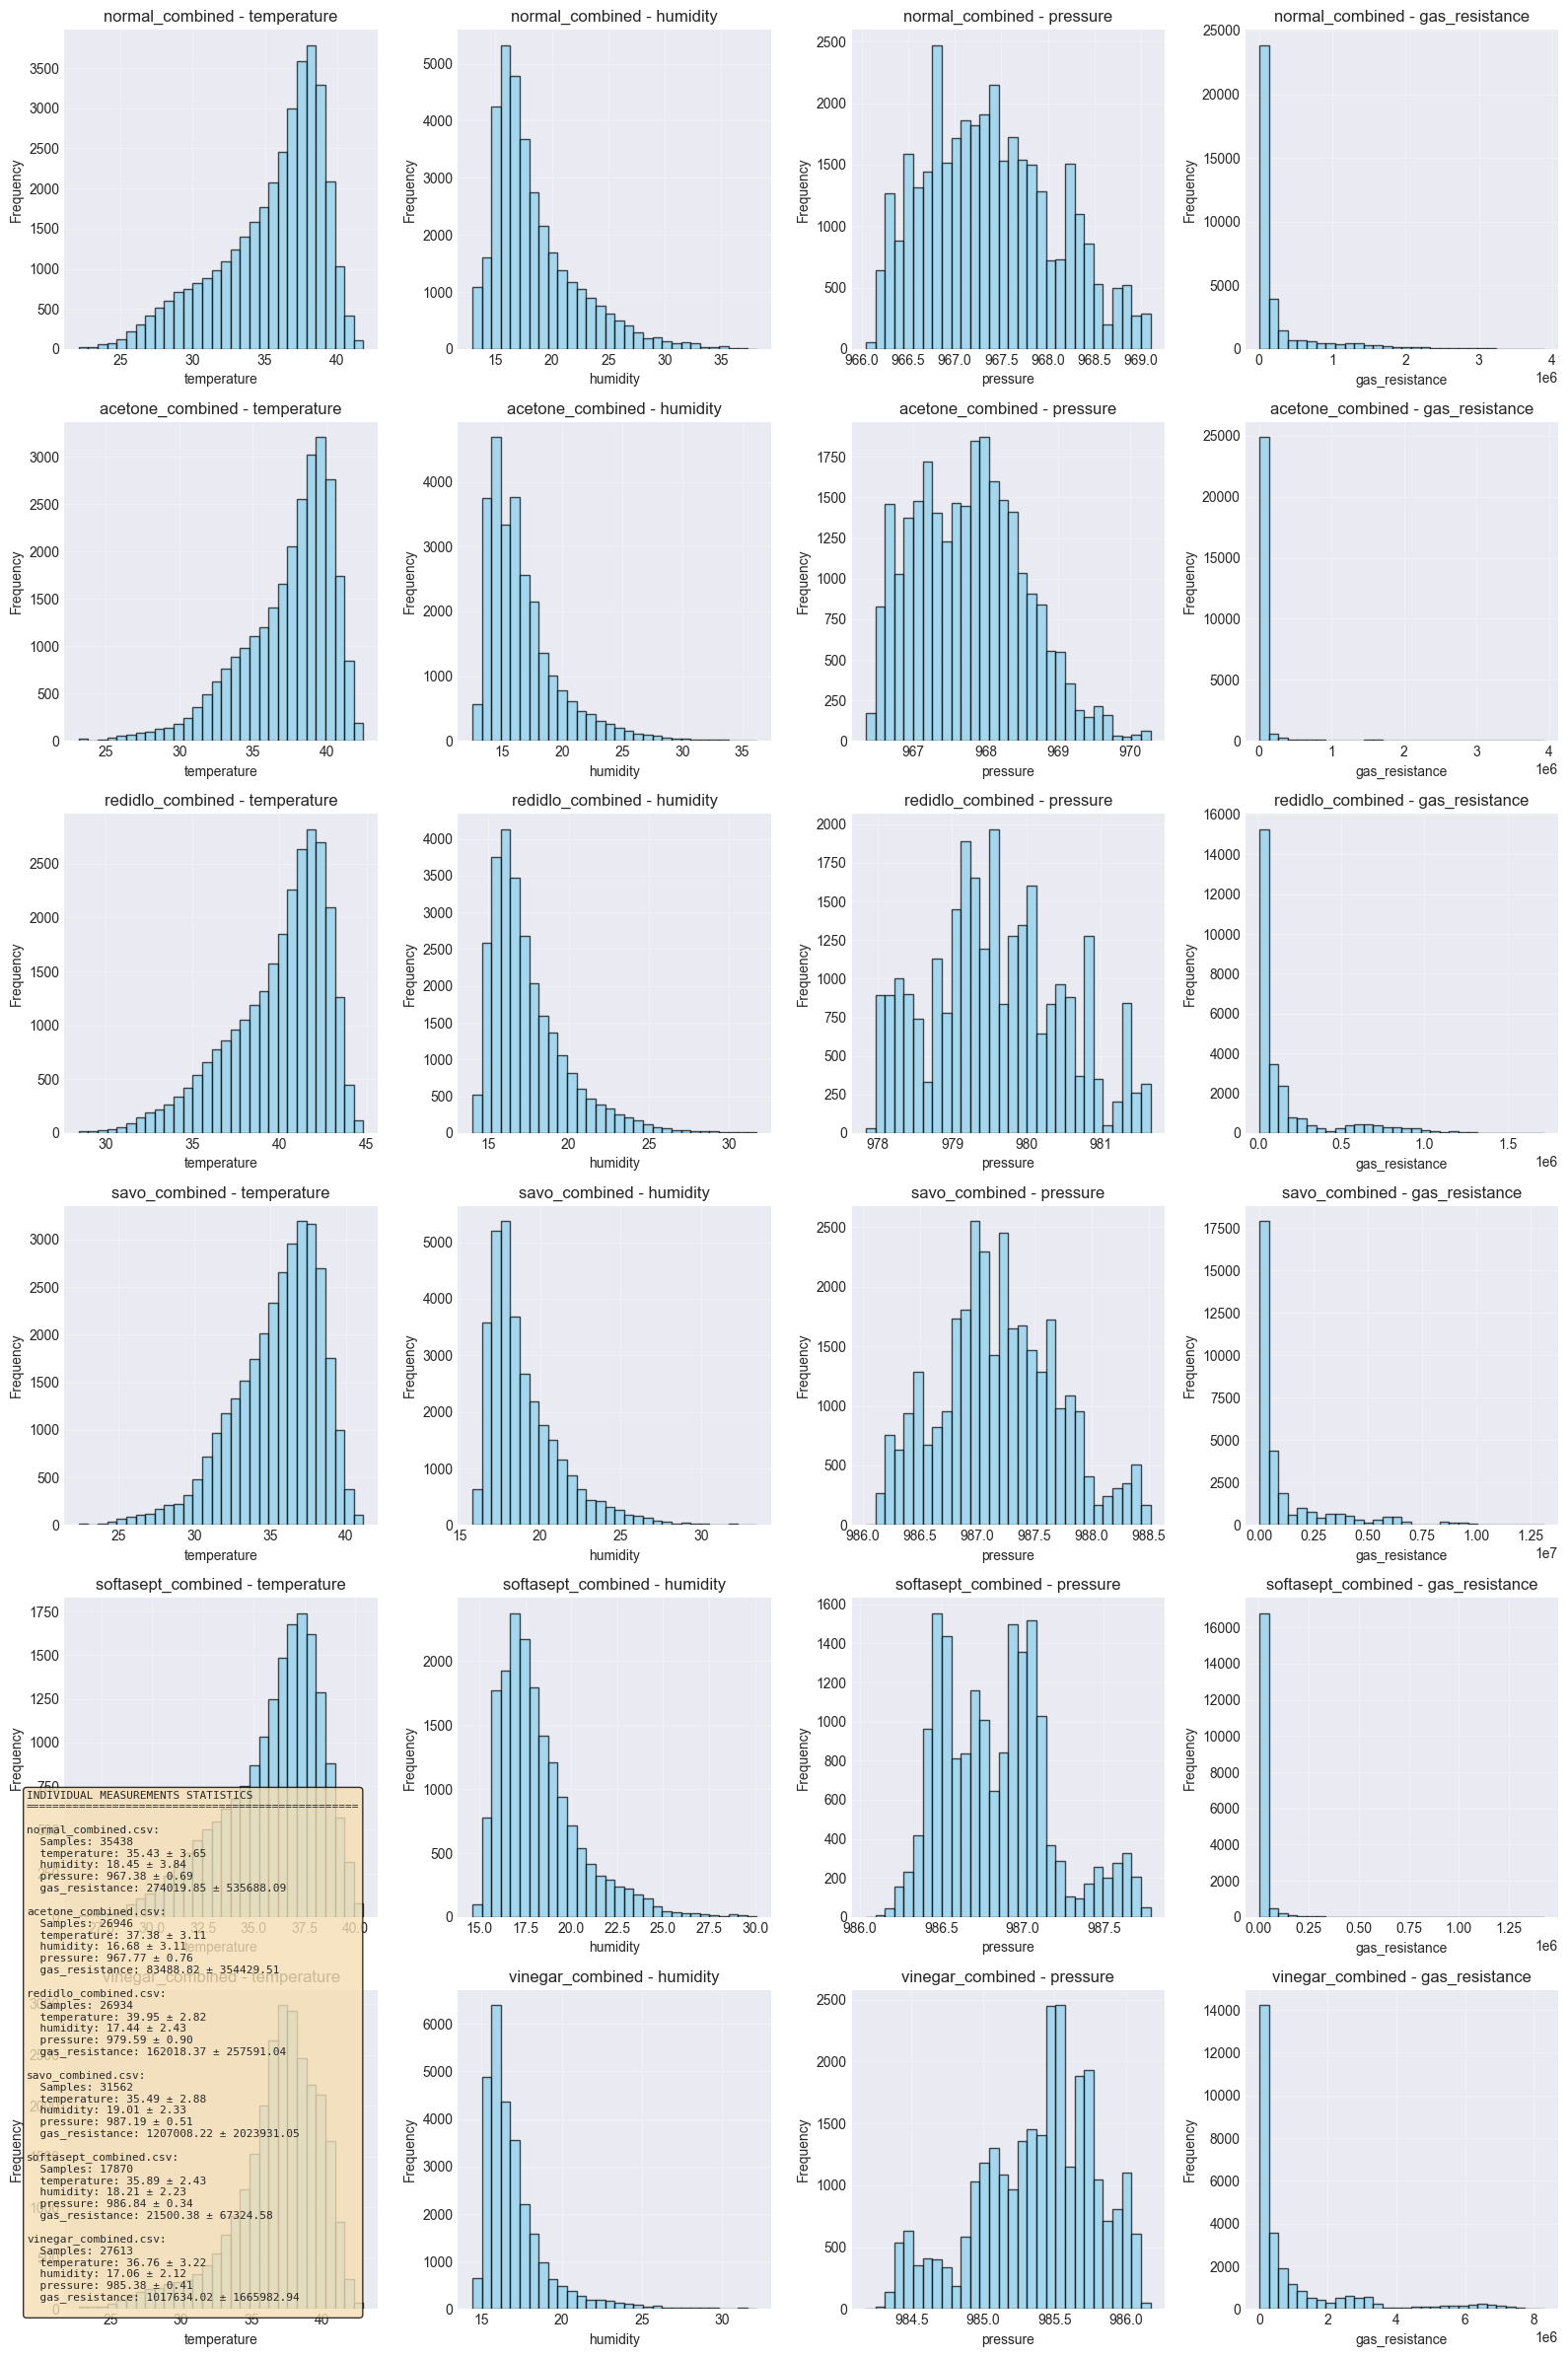

In [106]:
# ============================================================================
# PART 4: VISUALIZATION - INDIVIDUAL MEASUREMENTS
# ============================================================================

print("\n" + "="*80)
print("PART 4: VISUALIZATION - INDIVIDUAL MEASUREMENTS")
print("="*80)

fig, axes = plt.subplots(len(individual_dfs), len(sensor_cols), figsize=(16, 4*len(individual_dfs)))

if len(individual_dfs) == 1:
    axes = axes.reshape(1, -1)

for idx, (filename, df) in enumerate(individual_dfs.items()):
    print(f"\nVisualizing: {filename}")
    
    for col_idx, col in enumerate(sensor_cols):
        ax = axes[idx, col_idx]
        
        if col in df.columns:
            ax.hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
            ax.set_title(f'{filename.split(".")[0]} - {col}')
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, f'{col} not found', ha='center', va='center',
                   transform=ax.transAxes)

plt.tight_layout()

# Add statistics text to the figure
stats_text = "INDIVIDUAL MEASUREMENTS STATISTICS\n"
stats_text += "="*50 + "\n"
for filename, df in individual_dfs.items():
    stats_text += f"\n{filename}:\n"
    stats_text += f"  Samples: {len(df)}\n"
    for col in sensor_cols:
        if col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            stats_text += f"  {col}: {mean:.2f} ± {std:.2f}\n"

# Add text to figure
fig.text(0.02, 0.02, stats_text, fontsize=8, family='monospace', 
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.savefig('01_individual_measurements_distributions.png', dpi=150, bbox_inches='tight')
print(f"\n✓ PART 4 COMPLETE: Individual measurements visualized")
print(f"  Saved: 01_individual_measurements_distributions.png (with statistics)\n")

# Display in Jupyter
print("Displaying image in Jupyter Notebook:")
display(Image('01_individual_measurements_distributions.png'))
plt.show()
plt.close()


PART 5: MEASUREMENT COMPARISON - BOX PLOTS

✓ PART 5 COMPLETE: Measurement comparison box plots created
  Saved: 02_measurement_comparison_boxplots.png (with statistics)

Displaying image in Jupyter Notebook:


NameError: name 'Image' is not defined

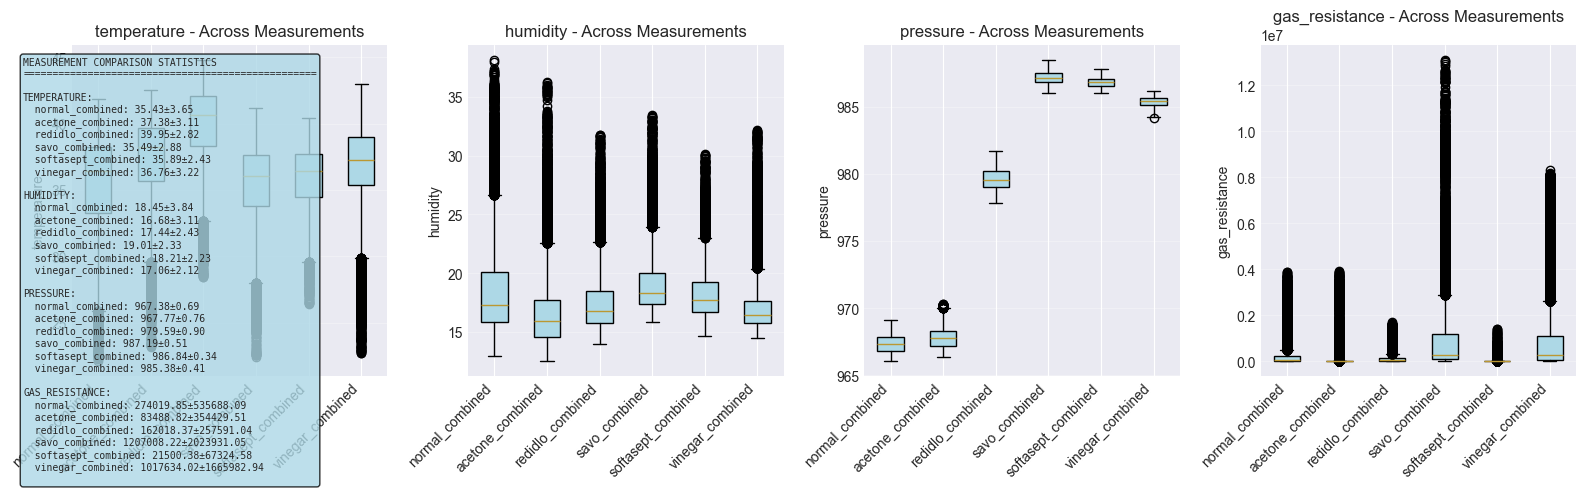

In [107]:
# ============================================================================
# PART 5: BOX PLOTS - MEASUREMENT COMPARISON
# ============================================================================

print("\n" + "="*80)
print("PART 5: MEASUREMENT COMPARISON - BOX PLOTS")
print("="*80)

fig, axes = plt.subplots(1, len(sensor_cols), figsize=(16, 5))

for col_idx, col in enumerate(sensor_cols):
    ax = axes[col_idx]
    
    data_to_plot = []
    labels = []
    
    for filename, df in individual_dfs.items():
        if col in df.columns:
            data_to_plot.append(df[col].values)
            labels.append(filename.replace('.csv', ''))
    
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
    
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    
    ax.set_ylabel(col)
    ax.set_title(f'{col} - Across Measurements')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()

# Create statistics text for box plots
stats_text = "MEASUREMENT COMPARISON STATISTICS\n"
stats_text += "="*50 + "\n"
for col in sensor_cols:
    stats_text += f"\n{col.upper()}:\n"
    for filename, df in individual_dfs.items():
        if col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            stats_text += f"  {filename.split('.')[0]}: {mean:.2f}±{std:.2f}\n"

# Add text to figure
fig.text(0.02, 0.02, stats_text, fontsize=7, family='monospace',
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.savefig('02_measurement_comparison_boxplots.png', dpi=150, bbox_inches='tight')
print(f"\n✓ PART 5 COMPLETE: Measurement comparison box plots created")
print(f"  Saved: 02_measurement_comparison_boxplots.png (with statistics)\n")

# Display in Jupyter
print("Displaying image in Jupyter Notebook:")
display(Image('02_measurement_comparison_boxplots.png'))
plt.show()
plt.close()

In [108]:
# ============================================================================
# PART 6: COMBINED DATA ANALYSIS & VISUALIZATION
# ============================================================================

if df_combined is not None:
    print("\n" + "="*80)
    print("PART 6: COMBINED DATA ANALYSIS & VISUALIZATION")
    print("="*80)
    
    # Clean data
    print("\nFinal data cleaning for ML...")
    df_ml = df_combined_clean.copy()  # Use already cleaned data from Part 3
    
    # Remove any remaining NaN/inf
    df_ml = df_ml.dropna(subset=sensor_cols, how='any')
    for col in sensor_cols:
        df_ml[col] = df_ml[col].replace([np.inf, -np.inf], np.nan)
    df_ml = df_ml.dropna(subset=sensor_cols, how='any')
    
    print(f"  Final ML dataset size: {len(df_ml)} rows")
    print(f"  Classes: {df_ml['label'].unique().tolist()}")
    
    # Feature engineering
    print("\nExtracting features...")
    
    features_list = []
    window_size = 50
    
    for label in df_ml['label'].unique():
        label_data = df_ml[df_ml['label'] == label].reset_index(drop=True)
        
        if len(label_data) < window_size:
            print(f"  Skipping {label}: insufficient data ({len(label_data)} < {window_size})")
            continue
        
        for i in range(0, len(label_data) - window_size, window_size // 2):
            window = label_data.iloc[i:i+window_size]
            features = {}
            
            for col in sensor_cols:
                if col in window.columns:
                    data = window[col].values
                    features[f'{col}_mean'] = np.mean(data)
                    features[f'{col}_std'] = np.std(data)
                    features[f'{col}_min'] = np.min(data)
                    features[f'{col}_max'] = np.max(data)
            
            features['label'] = label
            features_list.append(features)
    
    if len(features_list) == 0:
        print("  ✗ No valid features extracted!")
        print("\n✗ PART 6 SKIPPED: Insufficient cleaned data")
    else:
        features_df = pd.DataFrame(features_list)
        features_df = features_df.dropna()
        features_df = features_df.replace([np.inf, -np.inf], np.nan).dropna()
        
        print(f"✓ Extracted {len(features_df)} feature vectors")
    
    # Prepare data for ML
    X = features_df.drop('label', axis=1).values
    y = features_df['label'].values
    y_binary = (y != 'normal').astype(int)
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Visualization
    fig = plt.figure(figsize=(18, 10))
    
    # PCA 2D
    print("\nPerforming PCA...")
    pca2d = PCA(n_components=2)
    X_pca2d = pca2d.fit_transform(X_scaled)
    
    ax1 = plt.subplot(2, 3, 1)
    for label in np.unique(y):
        mask = y == label
        ax1.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], alpha=0.6, label=label, s=50)
    ax1.set_xlabel(f'PC1 ({pca2d.explained_variance_ratio_[0]:.1%})')
    ax1.set_ylabel(f'PC2 ({pca2d.explained_variance_ratio_[1]:.1%})')
    ax1.set_title('PCA (2D)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # PCA 3D
    pca3d = PCA(n_components=3)
    X_pca3d = pca3d.fit_transform(X_scaled)
    
    ax2 = plt.subplot(2, 3, 2, projection='3d')
    for label in np.unique(y):
        mask = y == label
        ax2.scatter(X_pca3d[mask, 0], X_pca3d[mask, 1], X_pca3d[mask, 2],
                   alpha=0.6, label=label, s=50)
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_zlabel('PC3')
    ax2.set_title('PCA (3D)')
    ax2.legend()
    
    # t-SNE
    if HAS_TSNE and len(X_scaled) > 20:
        print("Performing t-SNE...")
        try:
            tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)//3))
            X_tsne = tsne.fit_transform(X_scaled)
            
            ax3 = plt.subplot(2, 3, 3)
            for label in np.unique(y):
                mask = y == label
                ax3.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.6, label=label, s=50)
            ax3.set_xlabel('t-SNE 1')
            ax3.set_ylabel('t-SNE 2')
            ax3.set_title('t-SNE')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        except:
            pass
    
    # Variance explained
    pca_full = PCA()
    pca_full.fit(X_scaled)
    cumsum = np.cumsum(pca_full.explained_variance_ratio_)
    
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(range(1, min(31, len(cumsum)+1)), cumsum[:30], 'bo-')
    ax4.axhline(y=0.95, color='r', linestyle='--')
    ax4.set_xlabel('Number of Components')
    ax4.set_ylabel('Cumulative Variance')
    ax4.set_title('Variance Explained')
    ax4.grid(True, alpha=0.3)
    
    # Class distribution
    ax5 = plt.subplot(2, 3, 5)
    class_counts = features_df['label'].value_counts()
    ax5.bar(class_counts.index, class_counts.values, color=['green', 'red', 'blue'][:len(class_counts)])
    ax5.set_ylabel('Count')
    ax5.set_title('Class Distribution')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Feature importance (variance by feature)
    ax6 = plt.subplot(2, 3, 6)
    feature_variance = np.var(X_scaled, axis=0)
    top_features_idx = np.argsort(feature_variance)[-10:]
    feature_names = [f.replace('_', '\n') for f in features_df.drop('label', axis=1).columns]
    top_names = [feature_names[i] for i in top_features_idx]
    ax6.barh(range(len(top_features_idx)), feature_variance[top_features_idx])
    ax6.set_yticks(range(len(top_features_idx)))
    ax6.set_yticklabels(top_names, fontsize=8)
    ax6.set_xlabel('Variance')
    ax6.set_title('Top 10 Important Features')
    ax6.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('03_combined_data_analysis.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ PART 6 COMPLETE: Combined data analysis with PCA/t-SNE completed")
    print(f"  Saved: 03_combined_data_analysis.png")
    plt.close()
    


PART 6: COMBINED DATA ANALYSIS & VISUALIZATION

Final data cleaning for ML...
  Final ML dataset size: 130925 rows
  Classes: ['acetone', 'redidlo', 'savo', 'softasept', 'vinegar']

Extracting features...
✓ Extracted 5229 feature vectors

Performing PCA...
Performing t-SNE...

✓ PART 6 COMPLETE: Combined data analysis with PCA/t-SNE completed
  Saved: 03_combined_data_analysis.png


In [117]:
# ============================================================================
# LOAD DATA
# ============================================================================

print("\n" + "="*80)
print("LOADING 6 MEASUREMENTS + COMBINED DATA")
print("="*80)

# Load combined data
df_combined = pd.read_csv('combined_all_data.csv')

print(f"\n✓ Loaded combined_all_data.csv")
print(f"  Shape: {df_combined.shape}")
print(f"  Classes: {df_combined['label'].unique().tolist()}")

# Data cleaning
initial_shape = df_combined.shape
sensor_cols = ['temperature', 'humidity', 'pressure', 'gas_resistance']

df_combined = df_combined.dropna(subset=sensor_cols, how='all')
for col in sensor_cols:
    if col in df_combined.columns:
        df_combined[col] = df_combined[col].fillna(method='ffill').fillna(method='bfill')

df_combined = df_combined.dropna(subset=sensor_cols, how='any')
for col in sensor_cols:
    if col in df_combined.columns:
        median_val = df_combined[col].replace([np.inf, -np.inf], np.nan).median()
        df_combined[col] = df_combined[col].replace([np.inf, -np.inf], median_val)

print(f"  After cleaning: {df_combined.shape}")
print(f"  Classes: {df_combined['label'].unique().tolist()}")


LOADING 6 MEASUREMENTS + COMBINED DATA

✓ Loaded combined_all_data.csv
  Shape: (166363, 18)
  Classes: ['normal', 'acetone', 'redidlo', 'savo', 'softasept', 'vinegar']
  After cleaning: (130925, 18)
  Classes: ['acetone', 'redidlo', 'savo', 'softasept', 'vinegar']


In [118]:
# ============================================================================
# DEFINE COLORS FOR 6 MEASUREMENTS
# ============================================================================

# 6 distinct colors for 6 measurements
color_map = {
    'normal': '#FF6B6B',        # Red
    'acetone': '#4ECDC4',       # Teal
    'redidlo': '#FFE66D',       # Yellow
    'savo': '#95E1D3',          # Mint
    'softasept': '#A29BFE',     # Purple
    'vinegar': '#FD79A8'        # Pink
}

# Get unique classes (measurements)
classes = df_combined['label'].unique()
print(f"\n6 Measurements/Classes:")
for i, cls in enumerate(classes, 1):
    count = len(df_combined[df_combined['label'] == cls])
    color = color_map.get(cls.lower(), f'C{i}')
    print(f"  {i}. {cls.upper():15s} - {count:6d} samples - Color: {color}")


6 Measurements/Classes:
  1. ACETONE         -  26946 samples - Color: #4ECDC4
  2. REDIDLO         -  26934 samples - Color: #FFE66D
  3. SAVO            -  31562 samples - Color: #95E1D3
  4. SOFTASEPT       -  17870 samples - Color: #A29BFE
  5. VINEGAR         -  27613 samples - Color: #FD79A8



VISUALIZATION 1: RAW SENSOR DISTRIBUTIONS

✓ Saved: 05_six_measurements_raw_scatter.png
Displaying image in Jupyter Notebook:


NameError: name 'Image' is not defined

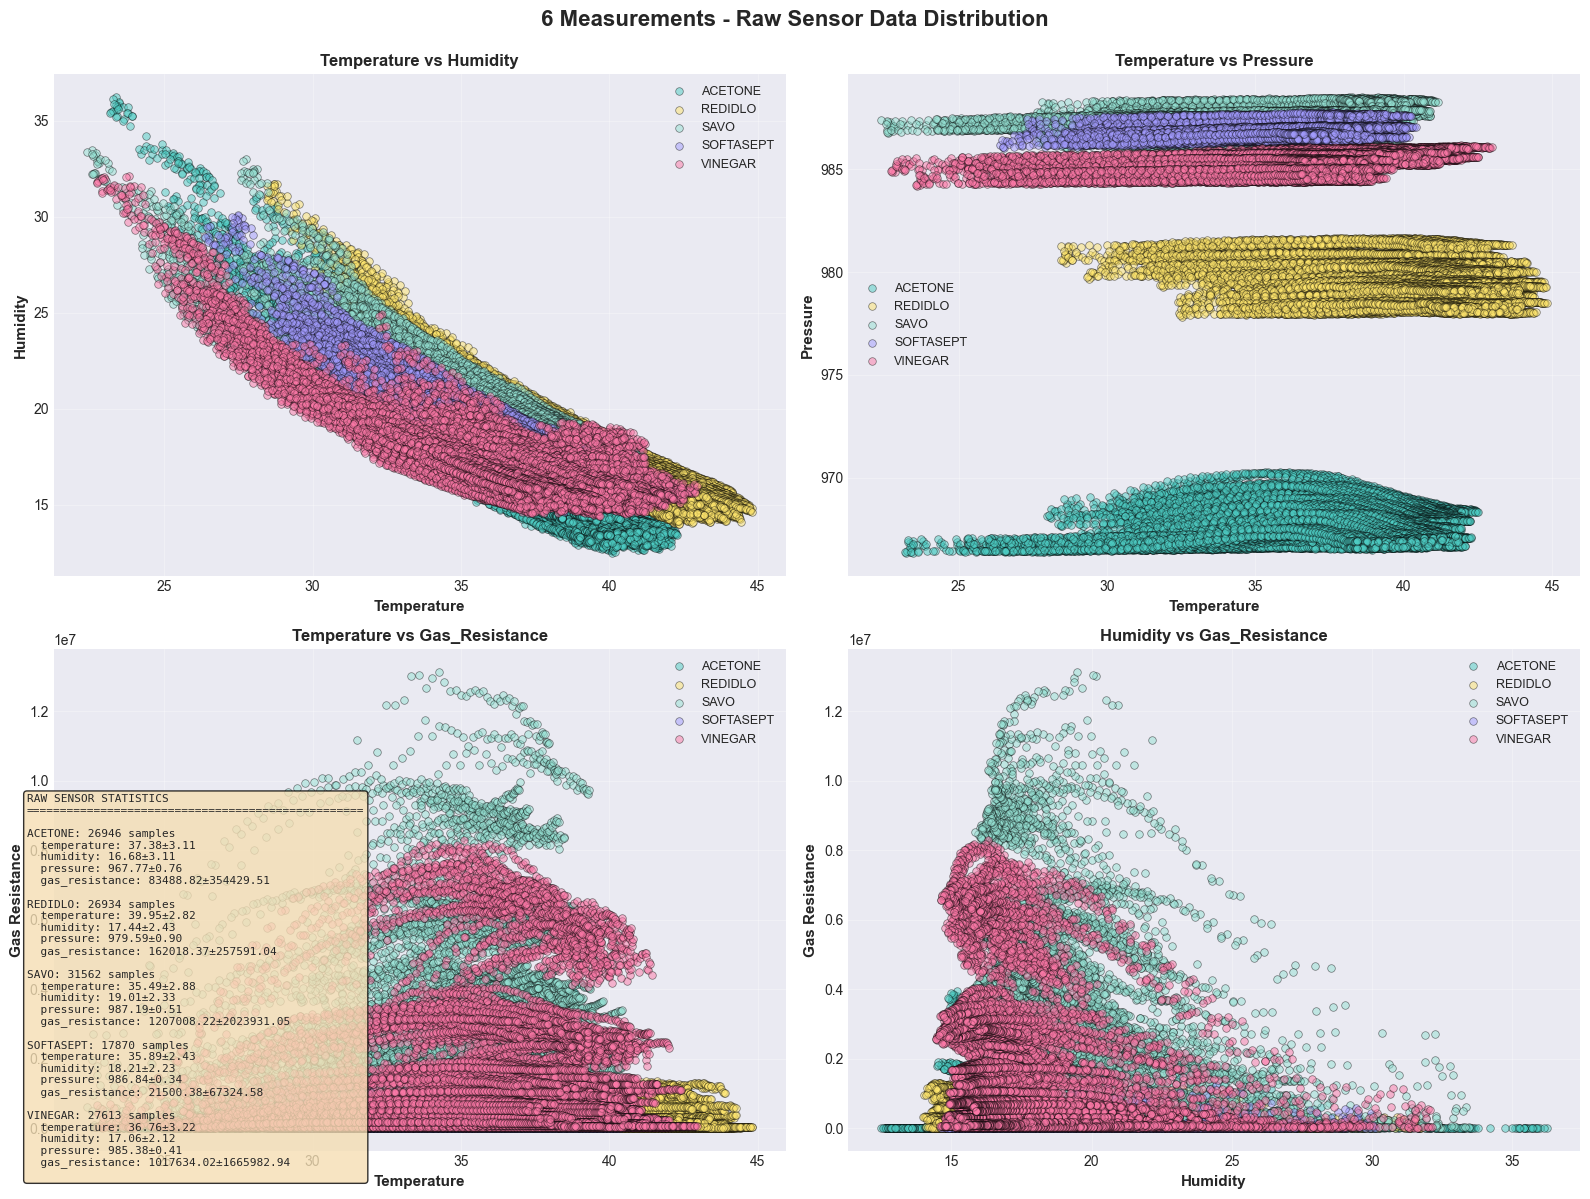

In [119]:
# ============================================================================
# VISUALIZATION 1: RAW SENSOR SCATTER PLOTS
# ============================================================================

print("\n" + "="*80)
print("VISUALIZATION 1: RAW SENSOR DISTRIBUTIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('6 Measurements - Raw Sensor Data Distribution', fontsize=16, fontweight='bold', y=0.995)

sensor_pairs = [
    ('temperature', 'humidity'),
    ('temperature', 'pressure'),
    ('temperature', 'gas_resistance'),
    ('humidity', 'gas_resistance')
]

for idx, (ax, (col1, col2)) in enumerate(zip(axes.flat, sensor_pairs)):
    for cls in classes:
        class_data = df_combined[df_combined['label'] == cls]
        color = color_map.get(cls.lower(), f'C{idx}')
        
        ax.scatter(class_data[col1], class_data[col2], 
                  alpha=0.5, s=30, label=cls.upper(), color=color, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(col1.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel(col2.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_title(f'{col1.title()} vs {col2.title()}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

# Add statistics
stats_text = "RAW SENSOR STATISTICS\n"
stats_text += "="*50 + "\n"
for cls in classes:
    class_data = df_combined[df_combined['label'] == cls]
    stats_text += f"\n{cls.upper()}: {len(class_data)} samples\n"
    for col in sensor_cols:
        mean = class_data[col].mean()
        std = class_data[col].std()
        if not np.isnan(mean):
            stats_text += f"  {col}: {mean:.2f}±{std:.2f}\n"

fig.text(0.02, 0.02, stats_text, fontsize=8, family='monospace',
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('05_six_measurements_raw_scatter.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: 05_six_measurements_raw_scatter.png")
print("Displaying image in Jupyter Notebook:")
display(Image('05_six_measurements_raw_scatter.png'))
plt.show()
plt.close()


VISUALIZATION 2: PCA 2D - 6 MEASUREMENTS

✓ Saved: 06_six_measurements_pca2d.png
Displaying image in Jupyter Notebook:


NameError: name 'Image' is not defined

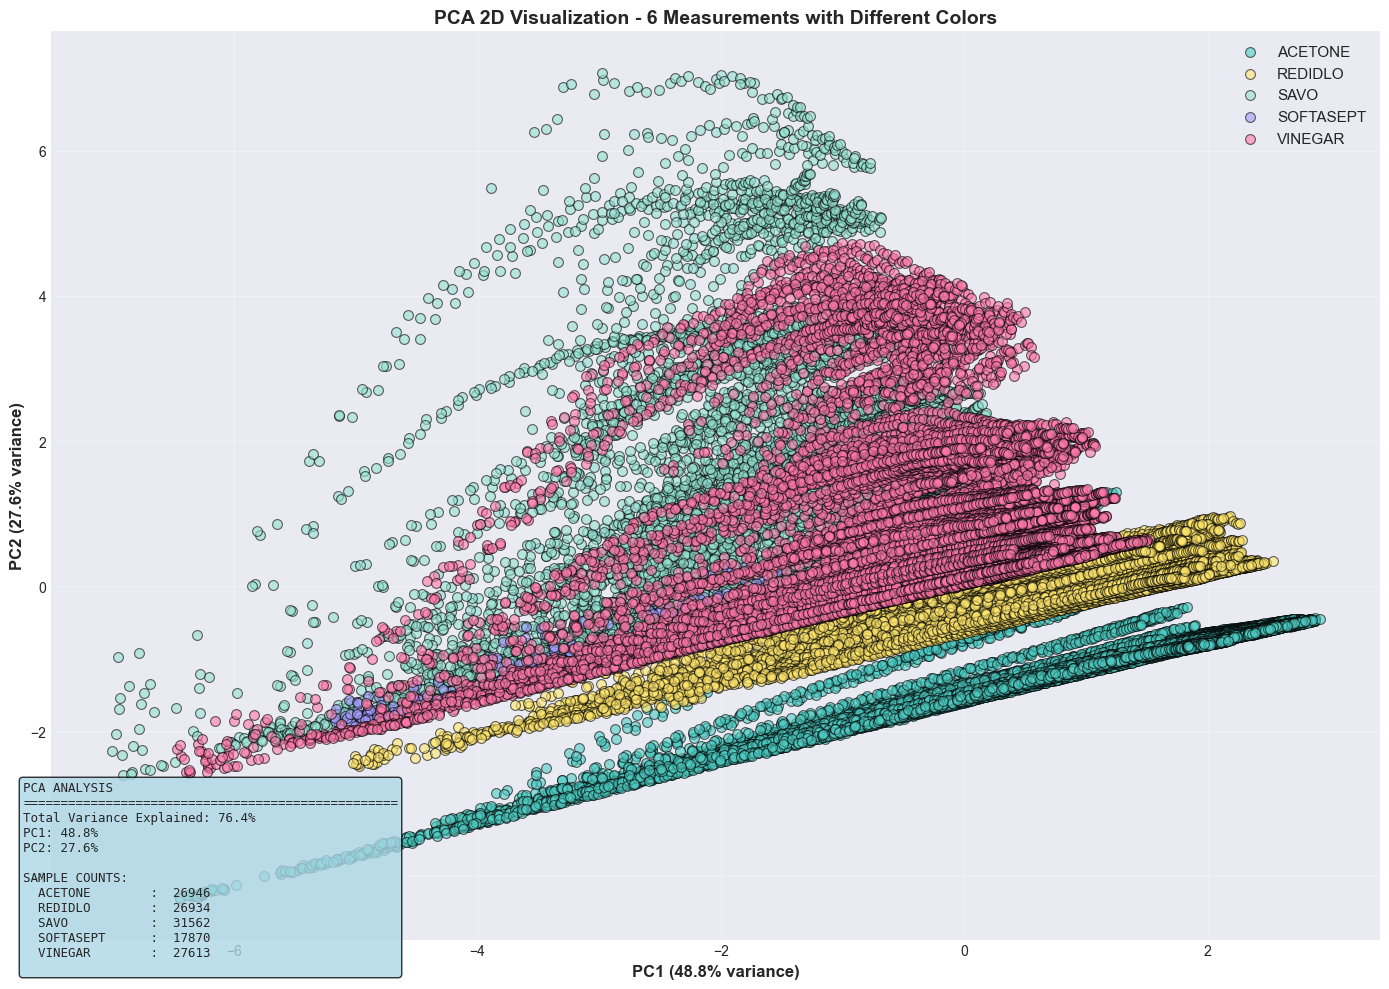

In [120]:
# ============================================================================
# VISUALIZATION 2: PCA 2D WITH COLORED DOTS
# ============================================================================

print("\n" + "="*80)
print("VISUALIZATION 2: PCA 2D - 6 MEASUREMENTS")
print("="*80)

# Prepare data
X = df_combined[sensor_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

for cls in classes:
    mask = df_combined['label'] == cls
    color = color_map.get(cls.lower(), f'C{0}')
    
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], 
              alpha=0.6, s=50, label=cls.upper(), color=color, 
              edgecolors='black', linewidth=0.8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('PCA 2D Visualization - 6 Measurements with Different Colors', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

# Add statistics
stats_text = f"PCA ANALYSIS\n"
stats_text += "="*50 + "\n"
stats_text += f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.1%}\n"
stats_text += f"PC1: {pca.explained_variance_ratio_[0]:.1%}\n"
stats_text += f"PC2: {pca.explained_variance_ratio_[1]:.1%}\n\n"
stats_text += "SAMPLE COUNTS:\n"
for cls in classes:
    count = len(df_combined[df_combined['label'] == cls])
    stats_text += f"  {cls.upper():15s}: {count:6d}\n"

fig.text(0.02, 0.02, stats_text, fontsize=9, family='monospace',
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.savefig('06_six_measurements_pca2d.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: 06_six_measurements_pca2d.png")
print("Displaying image in Jupyter Notebook:")
display(Image('06_six_measurements_pca2d.png'))
plt.show()
plt.close()


VISUALIZATION 3: PCA 3D - 6 MEASUREMENTS

✓ Saved: 07_six_measurements_pca3d.png
Displaying image in Jupyter Notebook:


NameError: name 'Image' is not defined

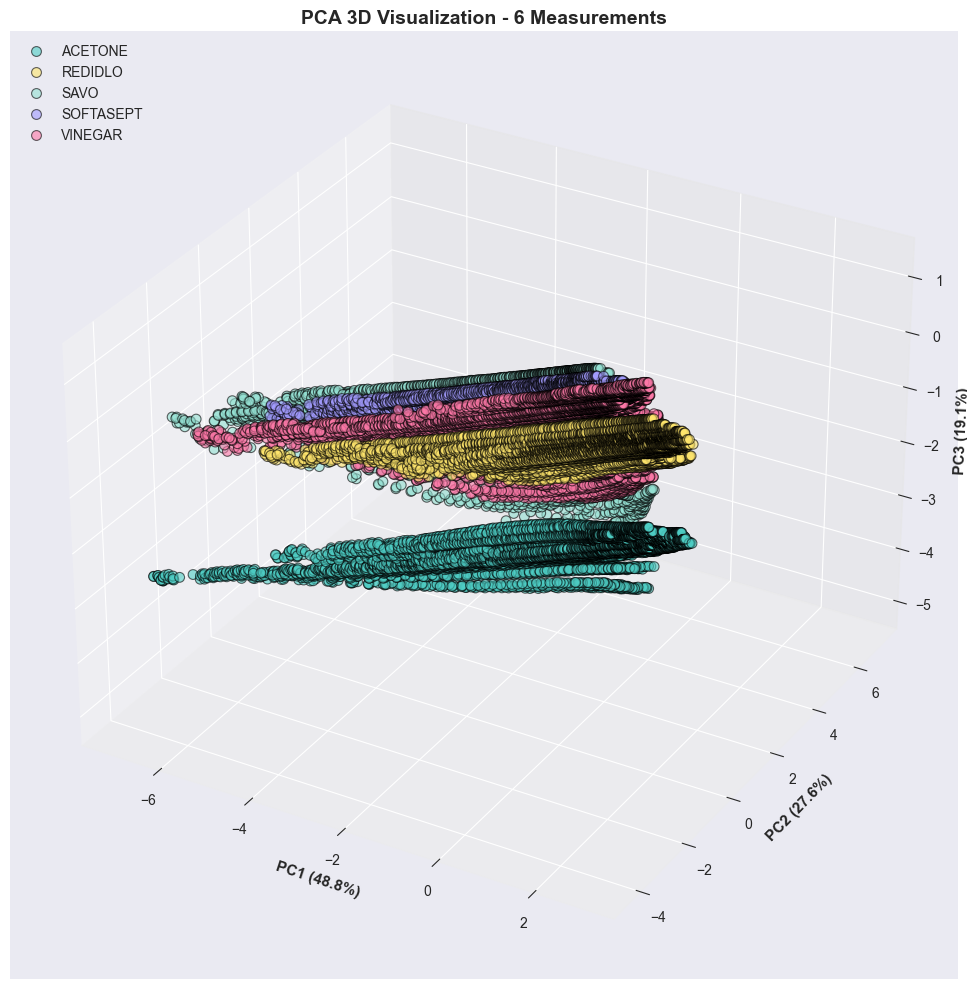

In [121]:
# ============================================================================
# VISUALIZATION 3: PCA 3D WITH COLORED DOTS
# ============================================================================

print("\n" + "="*80)
print("VISUALIZATION 3: PCA 3D - 6 MEASUREMENTS")
print("="*80)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for cls in classes:
    mask = df_combined['label'] == cls
    color = color_map.get(cls.lower(), f'C{0}')
    
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
              alpha=0.6, s=50, label=cls.upper(), color=color, edgecolors='black', linewidth=0.8)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontsize=11, fontweight='bold')
ax.set_title('PCA 3D Visualization - 6 Measurements', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('07_six_measurements_pca3d.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: 07_six_measurements_pca3d.png")
print("Displaying image in Jupyter Notebook:")
display(Image('07_six_measurements_pca3d.png'))
plt.show()
plt.close()

In [122]:
# ============================================================================
# VISUALIZATION 4: t-SNE WITH COLORED DOTS
# ============================================================================

print("\n" + "="*80)
print("VISUALIZATION 4: t-SNE - 6 MEASUREMENTS")
print("="*80)

try:
    tsne = TSNE(n_components=2, random_state=42, n_iter=1000, perplexity=min(30, len(X_scaled)//3))
    X_tsne = tsne.fit_transform(X_scaled)
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    for cls in classes:
        mask = df_combined['label'] == cls
        color = color_map.get(cls.lower(), f'C{0}')
        
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                  alpha=0.6, s=50, label=cls.upper(), color=color,
                  edgecolors='black', linewidth=0.8)
    
    ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
    ax.set_title('t-SNE Visualization - 6 Measurements with Different Colors', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    stats_text = "t-SNE ANALYSIS\n"
    stats_text += "="*50 + "\n"
    stats_text += "t-SNE Visualization\n"
    stats_text += "Non-linear dimensionality reduction\n\n"
    stats_text += "MEASUREMENTS:\n"
    for cls in classes:
        count = len(df_combined[df_combined['label'] == cls])
        stats_text += f"  {cls.upper():15s}: {count:6d}\n"
    
    fig.text(0.02, 0.02, stats_text, fontsize=9, family='monospace',
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('08_six_measurements_tsne.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved: 08_six_measurements_tsne.png")
    print("Displaying image in Jupyter Notebook:")
    display(Image('08_six_measurements_tsne.png'))
    plt.show()
    plt.close()
    
except Exception as e:
    print(f"✗ t-SNE failed: {e}")



VISUALIZATION 4: t-SNE - 6 MEASUREMENTS
✗ t-SNE failed: TSNE.__init__() got an unexpected keyword argument 'n_iter'



VISUALIZATION 6: DENSITY SCATTER - ALL SENSORS

✓ Saved: 10_six_measurements_density.png
Displaying image in Jupyter Notebook:


NameError: name 'Image' is not defined

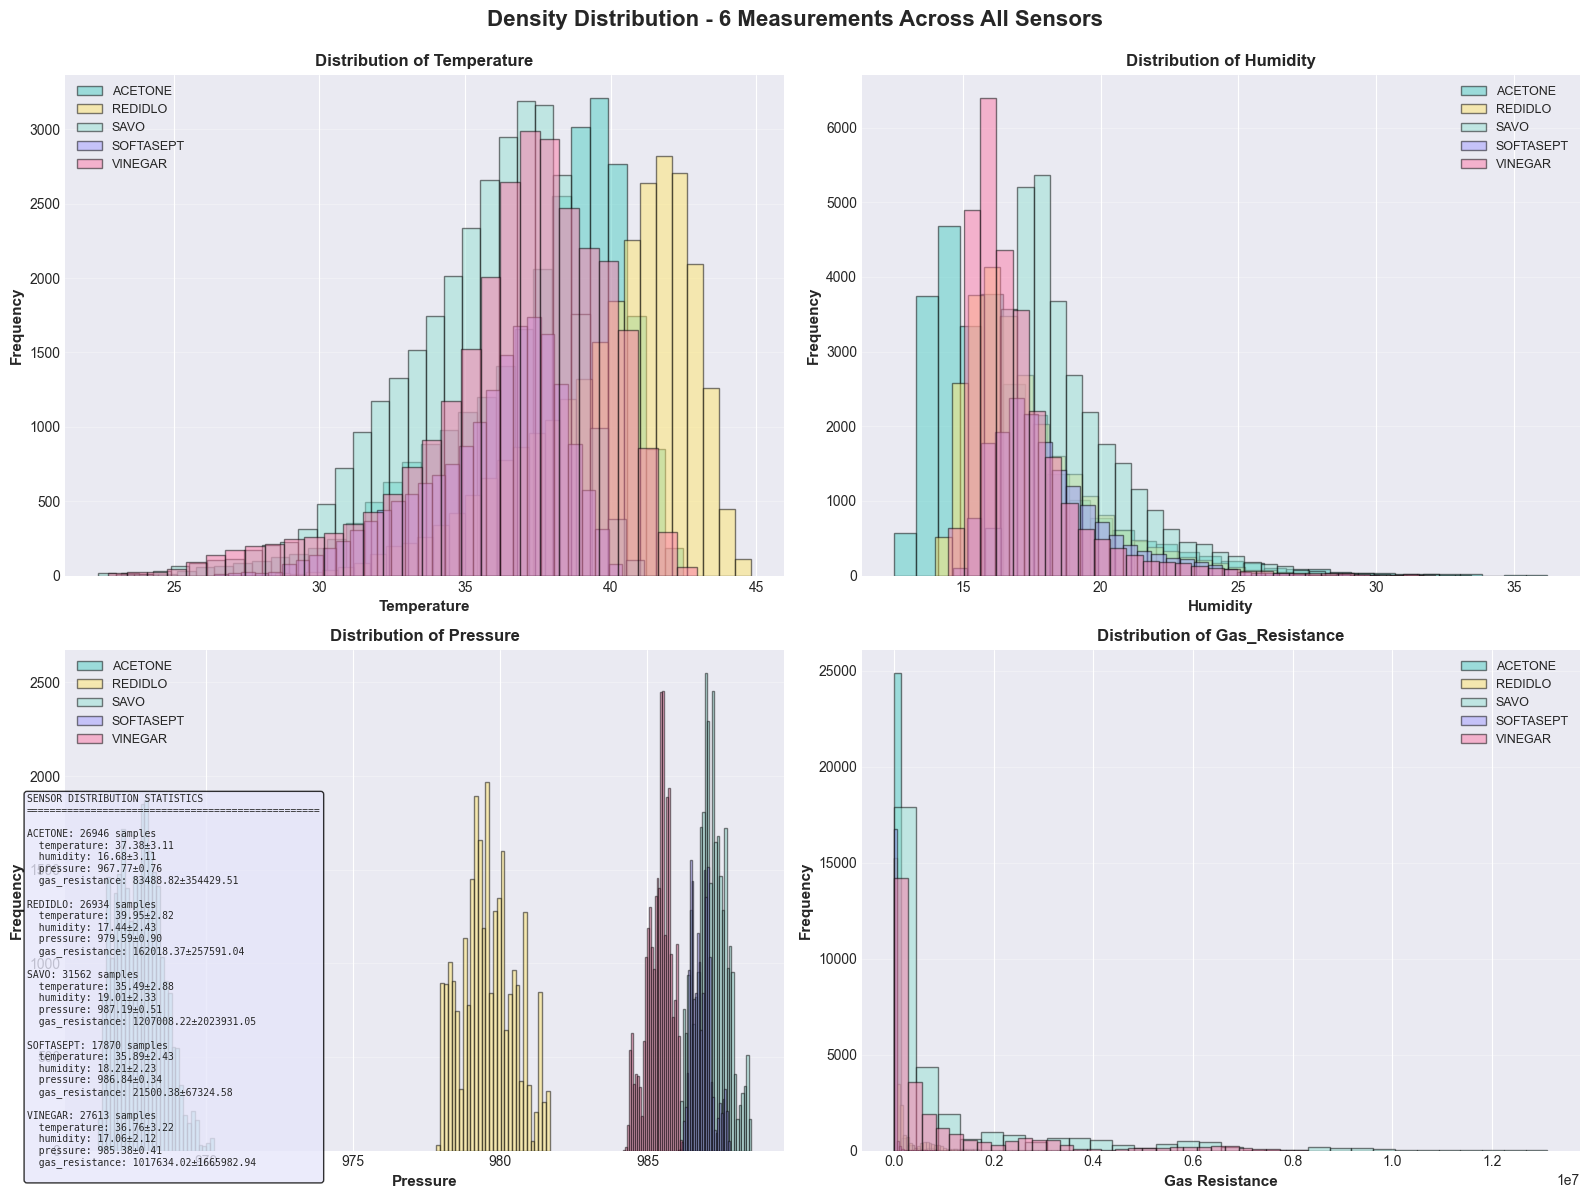

In [123]:
print("\n" + "="*80)
print("VISUALIZATION 6: DENSITY SCATTER - ALL SENSORS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Density Distribution - 6 Measurements Across All Sensors', fontsize=16, fontweight='bold', y=0.995)

for idx, (ax, col) in enumerate(zip(axes.flat, sensor_cols)):
    for cls in classes:
        class_data = df_combined[df_combined['label'] == cls]
        color = color_map.get(cls.lower(), f'C{idx}')
        
        # Create bins
        ax.hist(class_data[col], bins=30, alpha=0.5, label=cls.upper(), color=color, edgecolor='black')
    
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution of {col.title()}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

stats_text = "SENSOR DISTRIBUTION STATISTICS\n"
stats_text += "="*50 + "\n"
for cls in classes:
    class_data = df_combined[df_combined['label'] == cls]
    stats_text += f"\n{cls.upper()}: {len(class_data)} samples\n"
    for col in sensor_cols:
        mean = class_data[col].mean()
        std = class_data[col].std()
        if not np.isnan(mean):
            stats_text += f"  {col}: {mean:.2f}±{std:.2f}\n"

fig.text(0.02, 0.02, stats_text, fontsize=7, family='monospace',
         verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

plt.tight_layout()
plt.savefig('10_six_measurements_density.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: 10_six_measurements_density.png")
print("Displaying image in Jupyter Notebook:")
display(Image('10_six_measurements_density.png'))
plt.show()
plt.close()


In [124]:
# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✓ ALL VISUALIZATIONS COMPLETE!")
print("="*80)

print("\nGenerated 6 Visualizations (all saved + displayed in Jupyter):")
print("  1. 05_six_measurements_raw_scatter.png - Raw sensor scatter plots")
print("  2. 06_six_measurements_pca2d.png - PCA 2D with colored dots")
print("  3. 07_six_measurements_pca3d.png - PCA 3D with colored dots")
print("  4. 08_six_measurements_tsne.png - t-SNE with colored dots")
print("  5. 09_six_measurements_umap.png - UMAP with colored dots")
print("  6. 10_six_measurements_density.png - Density distributions")

print("\nColor Legend:")
for cls in classes:
    color = color_map.get(cls.lower(), 'default')
    print(f"  {cls.upper():15s} - {color}")

print("\n✓ Script Complete!")


✓ ALL VISUALIZATIONS COMPLETE!

Generated 6 Visualizations (all saved + displayed in Jupyter):
  1. 05_six_measurements_raw_scatter.png - Raw sensor scatter plots
  2. 06_six_measurements_pca2d.png - PCA 2D with colored dots
  3. 07_six_measurements_pca3d.png - PCA 3D with colored dots
  4. 08_six_measurements_tsne.png - t-SNE with colored dots
  5. 09_six_measurements_umap.png - UMAP with colored dots
  6. 10_six_measurements_density.png - Density distributions

Color Legend:
  ACETONE         - #4ECDC4
  REDIDLO         - #FFE66D
  SAVO            - #95E1D3
  SOFTASEPT       - #A29BFE
  VINEGAR         - #FD79A8

✓ Script Complete!
